## Objective

This notebook performs a full pre-modelling quality inspection of the
`solusdt_fw60_2010_2605` sample to confirm it is suitable for LightGBM binary
classifier development. It is an exploratory analysis — every section ends with
a quantitative result and a written evaluation.

**Sample:** `solusdt_fw60_2010_2605` | **Asset:** SOLUSDT | **Granularity:** 1-minute candles  
**Date:** 2026-06-17 | **Spec:** `_doc_/analysis/3200_sampling_spec.md`  
**Data source:** `database/solusdt/samples/solusdt_fw60_2010_2605/sample.parquet`  
**Targets:** `trg_l_fw60_q90` (long, q90), `trg_s_fw60_q10` (short, q10)

In [1]:
import sys, json, pathlib, re, warnings
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

sys.path.insert(0, "src")
from table_formatting import format_analysis_table, display_analysis_table

CQ_COLORS = {
    "blue": "#1696d2", "black": "#000000", "gray_dark": "#353535",
    "gray": "#696969", "gray_light": "#d2d2d2",
    "yellow": "#fdbf11", "orange": "#f15a24", "red": "#ec008b",
}
CQ_SEQUENCE = [
    CQ_COLORS["blue"], CQ_COLORS["yellow"], CQ_COLORS["orange"],
    CQ_COLORS["gray"], CQ_COLORS["red"],
]

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (10, 5), "figure.dpi": 120,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.edgecolor": CQ_COLORS["gray"],
        "axes.labelcolor": CQ_COLORS["gray_dark"],
        "xtick.color": CQ_COLORS["gray_dark"],
        "ytick.color": CQ_COLORS["gray_dark"],
        "grid.color": CQ_COLORS["gray_light"],
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "legend.frameon": False,
    },
)
sns.set_palette(CQ_SEQUENCE)

# Locate project root (contains database/)
_root = pathlib.Path.cwd()
for _ in range(6):
    if (_root / "database").exists():
        break
    _root = _root.parent

SAMPLE_ID  = "solusdt_fw60_2010_2605"
SAMPLE_DIR = _root / "database" / "solusdt" / "samples" / SAMPLE_ID
SAMPLE_PARQUET = SAMPLE_DIR / "sample.parquet"
METADATA   = json.loads((SAMPLE_DIR / "metadata.json").read_text())
FOLDS_DATA = json.loads((SAMPLE_DIR / "folds.json").read_text())
FOLDS      = FOLDS_DATA["folds"]
TEST_INFO  = FOLDS_DATA["test"]

N_FOLDS = METADATA["n_folds"]
HORIZON = METADATA["target_horizon_minutes"]
TARGETS = ["trg_l_fw60_q90", "trg_s_fw60_q10"]

_schema   = pl.scan_parquet(str(SAMPLE_PARQUET)).collect_schema()
FEAT_COLS = [c for c in _schema.names() if c.startswith("feat_")]

def seg_fold(s: str) -> int | None:
    return None if s == "test" else int(s.split("_")[1])

def seg_split(s: str) -> str:
    return "test" if s == "test" else s.split("_")[2]

ALL_SEGS   = sorted(pl.scan_parquet(str(SAMPLE_PARQUET)).select("segment").unique().collect()["segment"].to_list())
TRAIN_SEGS = [s for s in ALL_SEGS if s.endswith("_train")]
VALID_SEGS = [s for s in ALL_SEGS if s.endswith("_valid")]

print(f"Root: {_root}")
print(f"Parquet: {SAMPLE_PARQUET}")
print(f"Features: {len(FEAT_COLS)} | Folds: {N_FOLDS} | Horizon: {HORIZON} bars")
print(f"Segments: {ALL_SEGS}")

Root: D:\repos\chronoquant
Parquet: D:\repos\chronoquant\database\solusdt\samples\solusdt_fw60_2010_2605\sample.parquet
Features: 208 | Folds: 5 | Horizon: 60 bars
Segments: ['fold_1_train', 'fold_1_valid', 'fold_2_train', 'fold_2_valid', 'fold_3_train', 'fold_3_valid', 'fold_4_train', 'fold_4_valid', 'fold_5_train', 'fold_5_valid', 'test']


## 1. Fold áttekintés — sorok és target eloszlás

### 1.1 Sor- és időszak statisztikák per fold

**Purpose.** Overview table of row counts, date ranges, and non-null target counts per fold-split — confirms the expanding-window structure.

**Method.** Groups `sample.parquet` by `segment` and aggregates row count, `open_time` min/max, and non-null target counts directly from the `segment` column.

**Interpretation.** Healthy: each successive train split is larger than the previous (expanding window), valid splits are equal size. NULL targets only at dataset tail (last 60 bars).

**Action rule.** Non-monotone train growth or zero rows in any segment is a blocker.

In [2]:
#| label: tbl-fold-overview
#| tbl-cap: "Fold overview — row counts and date ranges per segment"

seg_stats = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .select(["open_time", "segment"] + TARGETS)
    .group_by("segment")
    .agg([
        pl.len().alias("rows"),
        pl.col("open_time").min().alias("period_start"),
        pl.col("open_time").max().alias("period_end"),
        pl.col("trg_l_fw60_q90").is_not_null().sum().alias("n_l"),
        (pl.col("trg_l_fw60_q90") == True).sum().alias("pos_l"),
        pl.col("trg_s_fw60_q10").is_not_null().sum().alias("n_s"),
        (pl.col("trg_s_fw60_q10") == True).sum().alias("pos_s"),
    ])
    .with_columns([
        pl.col("segment").map_elements(seg_fold, return_dtype=pl.Int32).alias("fold"),
        pl.col("segment").map_elements(seg_split, return_dtype=pl.String).alias("split"),
    ])
    .sort(["fold", "split"], nulls_last=True)
    .collect()
)

tbl = seg_stats.select([
    pl.col("fold").cast(pl.String).fill_null("—").alias("Fold"),
    pl.col("split").alias("Split"),
    pl.col("period_start").dt.strftime("%Y-%m-%d").alias("Start"),
    pl.col("period_end").dt.strftime("%Y-%m-%d").alias("End"),
    pl.col("rows").alias("rows"),
    pl.col("n_l").alias("Non-null (L)"),
    pl.col("n_s").alias("Non-null (S)"),
]).to_pandas()

tbl["Split"] = tbl["Split"].str.capitalize()
display_analysis_table(tbl)

Fold,Split,Start,End,rows,Non-null (L),Non-null (S)
1,Train,2020-10-01,2022-09-30,1051140,1051140,1051140
1,Valid,2022-10-01,2023-03-29,259200,259200,259200
2,Train,2020-10-01,2023-03-29,1310340,1310340,1310340
2,Valid,2023-03-30,2023-09-25,259200,259200,259200
3,Train,2020-10-01,2023-09-25,1569540,1569540,1569540
3,Valid,2023-09-26,2024-03-23,259200,259200,259200
4,Train,2020-10-01,2024-03-23,1828740,1828740,1828740
4,Valid,2024-03-24,2024-09-19,259200,259200,259200
5,Train,2020-10-01,2024-09-19,2087940,2087940,2087940
5,Valid,2024-09-20,2025-03-18,259200,259200,259200


### 1.2 Target positive rate per fold

**Purpose.** Checks whether the positive label rate stays within the expected 8–12% band across all folds and both targets.

**Method.** Computes `sum(target == True) / count(target is not null)` per segment, per target, from the parquet `segment` column.

**Interpretation.** Healthy: all bars within 8–12%. Suspicious: any fold/split deviating more than ±3 pp from the band.

**Action rule.** Deviation > 5 pp from band in any fold: flag in Summary and consider a todo ticket for the Modeling Agent.

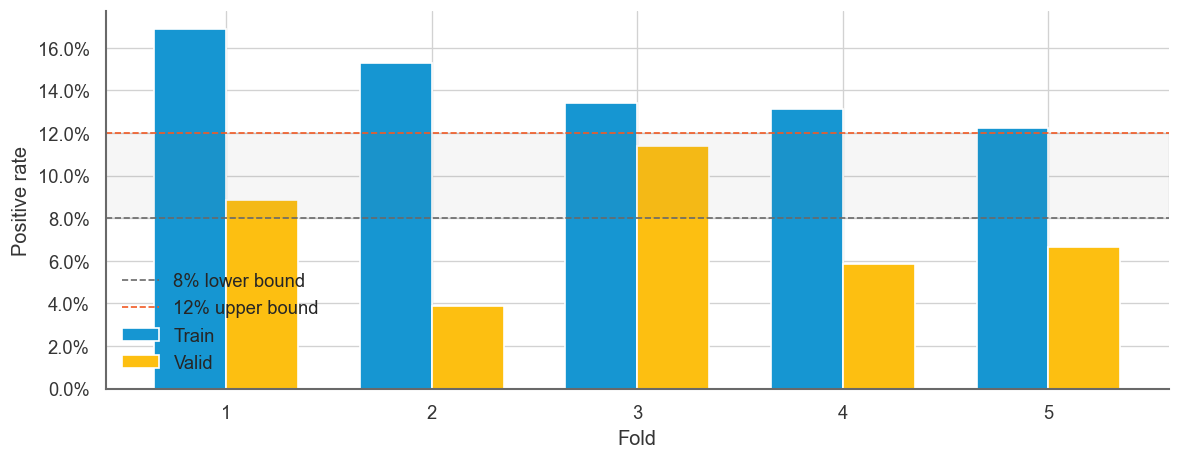

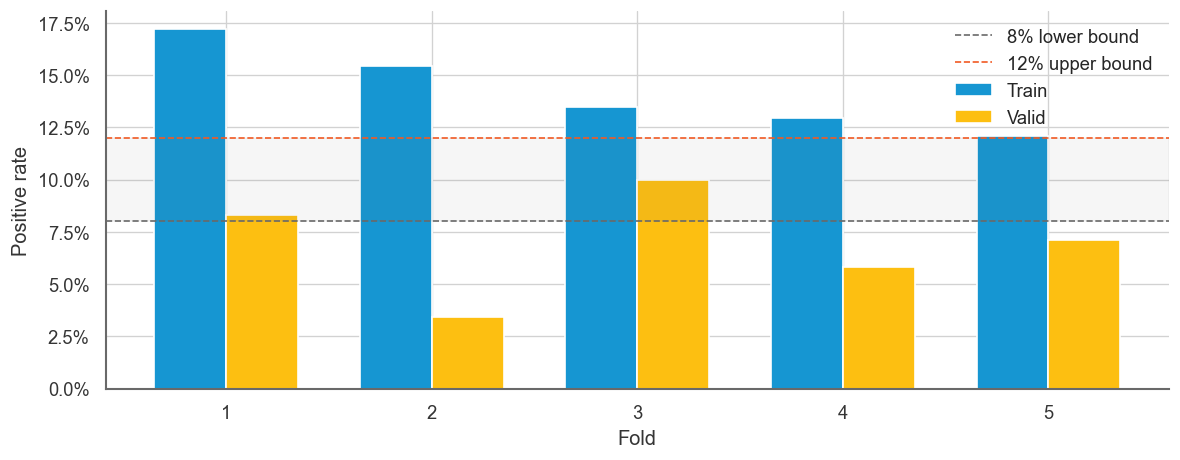

**Finding [Long]:** ⚠️ 8 segment(s) outside 8–12%: fold_1_train, fold_2_train, fold_2_valid, fold_3_train, fold_4_train, fold_4_valid, fold_5_train, fold_5_valid

**Finding [Short]:** ⚠️ 8 segment(s) outside 8–12%: fold_1_train, fold_2_train, fold_2_valid, fold_3_train, fold_4_train, fold_4_valid, fold_5_train, fold_5_valid

In [3]:
#| label: fig-positive-rate
#| fig-cap: "Target positive rate per fold and split"
#| fig-subcap:
#|   - "Long target (trg_l_fw60_q90)"
#|   - "Short target (trg_s_fw60_q10)"
#| layout-ncol: 1

rate_df = (
    seg_stats
    .with_columns([
        (pl.col("pos_l").cast(pl.Float64) / pl.col("n_l")).alias("rate_l"),
        (pl.col("pos_s").cast(pl.Float64) / pl.col("n_s")).alias("rate_s"),
        pl.col("fold").cast(pl.String).fill_null("test").alias("fold_label"),
    ])
    .to_pandas()
)

cv_only = rate_df[rate_df["split"].isin(["train", "valid"])].copy()

for rate_col, label in [("rate_l", "Long (q90)"), ("rate_s", "Short (q10)")]:
    pivot = cv_only.pivot_table(index="fold_label", columns="split", values=rate_col).reset_index()
    x = np.arange(len(pivot))
    w = 0.35
    fig, ax = plt.subplots(figsize=(10, 4))
    if "train" in pivot.columns:
        ax.bar(x - w/2, pivot["train"], width=w, color=CQ_COLORS["blue"], label="Train")
    if "valid" in pivot.columns:
        ax.bar(x + w/2, pivot["valid"], width=w, color=CQ_COLORS["yellow"], label="Valid")
    ax.axhline(0.08, linestyle="--", linewidth=1, color=CQ_COLORS["gray"], label="8% lower bound")
    ax.axhline(0.12, linestyle="--", linewidth=1, color=CQ_COLORS["orange"], label="12% upper bound")
    ax.axhspan(0.08, 0.12, alpha=0.06, color=CQ_COLORS["gray"])
    ax.set_xticks(x)
    ax.set_xticklabels(pivot["fold_label"])
    ax.set_xlabel("Fold")
    ax.set_ylabel("Positive rate")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
    ax.legend()
    plt.tight_layout()
    plt.show()

for rate_col, label in [("rate_l", "Long"), ("rate_s", "Short")]:
    out_of_band = cv_only[(cv_only[rate_col] < 0.08) | (cv_only[rate_col] > 0.12)]
    if out_of_band.empty:
        display(Markdown(f"**Finding [{label}]:** ✅ All train/valid segments within 8–12% positive rate band."))
    else:
        segs = ', '.join(out_of_band['segment'].tolist())
        display(Markdown(f"**Finding [{label}]:** ⚠️ {len(out_of_band)} segment(s) outside 8–12%: {segs}"))

### 1.3 Train méret növekedés (expanding window vizualizáció)

**Purpose.** Visually confirms the expanding-window character: each fold's train set starts at `data_start` and grows monotonically.

**Method.** Horizontal bar chart with train and valid windows per fold on the time axis, plus the test window.

**Interpretation.** All train bars must begin at the same date and grow successively. Valid bars should be roughly equal length.

**Action rule.** Any train/valid overlap or non-monotone growth is a blocker.

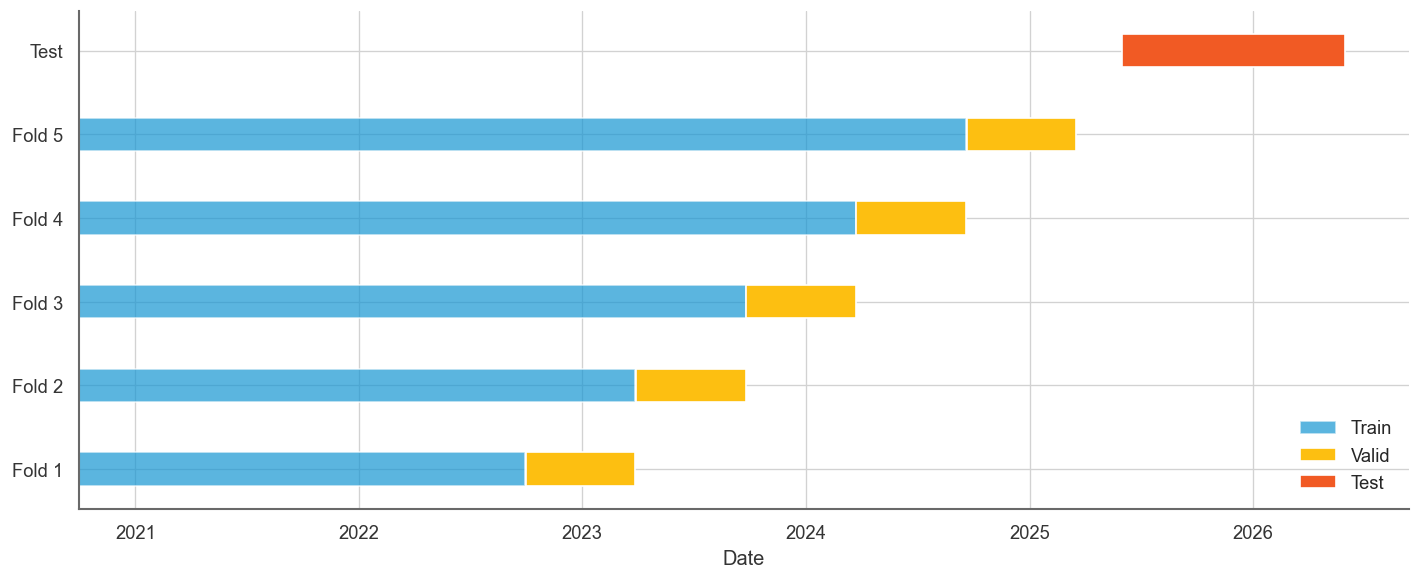

In [4]:
#| label: fig-expanding-window
#| fig-cap: "Expanding-window structure: train, valid, and test time ranges per fold"
#| fig-alt: "Horizontal bar chart showing time ranges of each fold's train/valid split plus the test set."

def pd_ts(s: str) -> pd.Timestamp:
    return pd.Timestamp(s[:19])

fig, ax = plt.subplots(figsize=(12, 5))
y_labels, y_pos = [], []

for fold in FOLDS:
    fn = fold["fold"]
    y  = fn - 1
    tr_s = pd_ts(fold["train_start"])
    tr_e = pd_ts(fold["train_end"])
    va_s = pd_ts(fold["valid_start"])
    va_e = pd_ts(fold["valid_end"])
    ax.barh(y, (tr_e - tr_s).days, left=mdates.date2num(tr_s.to_pydatetime()),
            height=0.4, color=CQ_COLORS["blue"], alpha=0.7,
            label="Train" if fn == 1 else "")
    ax.barh(y, (va_e - va_s).days, left=mdates.date2num(va_s.to_pydatetime()),
            height=0.4, color=CQ_COLORS["yellow"],
            label="Valid" if fn == 1 else "")
    y_labels.append(f"Fold {fn}")
    y_pos.append(y)

ts_s = pd_ts(TEST_INFO["start"])
ts_e = pd_ts(TEST_INFO["end"])
y_test = N_FOLDS
ax.barh(y_test, (ts_e - ts_s).days, left=mdates.date2num(ts_s.to_pydatetime()),
        height=0.4, color=CQ_COLORS["orange"], label="Test")
y_labels.append("Test")
y_pos.append(y_test)

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Date")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 2. Feature eloszlások és drift

### 2.1 Feature csoportok

**Purpose.** Classifies all `feat_*` columns into four semantic groups for downstream drift and correlation analysis.

**Method.** Regex-based matching on column names: `momentum` (RSI/MACD/ROC/Stoch/CCI/ADX), `volume` (vol/OBV/VWAP), `volatility` (ATR/BB/hist_vol/NATR), `other` (remainder).

In [5]:
_PATTERNS = {
    "momentum":   re.compile(r"rsi|macd|mom|roc|stoch|williams|cci|adx|sma_ratio|ema_ratio|wma_ratio|kama"),
    "volume":     re.compile(r"vol|obv|vwap"),
    "volatility": re.compile(r"atr|bb_|hist_vol|natr|range"),
}
GROUPS: dict[str, list[str]] = {}
for feat in FEAT_COLS:
    assigned = False
    for grp, pat in _PATTERNS.items():
        if pat.search(feat.lower()):
            GROUPS.setdefault(grp, []).append(feat)
            assigned = True
            break
    if not assigned:
        GROUPS.setdefault("other", []).append(feat)

for grp, cols in sorted(GROUPS.items()):
    print(f"{grp}: {len(cols)} features")

REPR = {
    grp: cols[:3]
    for grp, cols in GROUPS.items()
    if len(cols) >= 3
}
REPR_FLAT = [f for fs in REPR.values() for f in fs]

momentum: 28 features
other: 136 features
volatility: 20 features
volume: 24 features


### 2.2 NULL arányok per feature

**Purpose.** Identifies features with unexpected NULL rates and verifies leading-null patterns for windowed features.

**Method.** NULL ratio per feature across the entire sample (scan_parquet aggregation). Leading-null count: sorts by `open_time`, inspects first 500 rows per feature.

**Interpretation.** Windowed features must have leading NULLs consistent with their window size (e.g. `feat_rsi_14` → 13 leading NULLs). Any feature with NULL rate > 1% beyond the expected window is suspicious.

**Action rule.** Mid-sample NULLs → todo ticket for the Modeling Agent.

In [6]:
#| label: tbl-null-rates
#| tbl-cap: "Top-20 features by NULL rate across the entire sample"

# Batch by 50 columns to avoid OOM with 208 features × 9.6M rows
_null_results: dict[str, float] = {}
for _i in range(0, len(FEAT_COLS), 50):
    _batch = FEAT_COLS[_i:_i + 50]
    _agg = (
        pl.scan_parquet(str(SAMPLE_PARQUET))
        .select(_batch)
        .select([(pl.col(c).is_null().sum() / pl.len()).alias(c) for c in _batch])
        .collect()
    )
    for c in _batch:
        _null_results[c] = float(_agg[c][0])

null_df = pd.DataFrame({
    "feature":   FEAT_COLS,
    "null_rate": [_null_results[c] for c in FEAT_COLS],
}).sort_values("null_rate", ascending=False).reset_index(drop=True)

display_analysis_table(null_df.head(20))

high_null = null_df[null_df["null_rate"] > 0.01]
if high_null.empty:
    display(Markdown("**Finding:** ✅ No features exceed 1% NULL rate."))
else:
    display(Markdown(f"**Finding:** ⚠️ {len(high_null)} feature(s) > 1% NULL: {high_null['feature'].tolist()[:10]}"))

feature,null_rate
feat_signed_body_sma_30,0.47%
feat_wick_imbalance_sma_30,0.47%
feat_body_ratio_sma_30,0.47%
feat_cmf_20,0.34%
feat_body_ratio_sma_10,0.19%
feat_wick_imbalance_sma_10,0.19%
feat_signed_body_sma_10,0.19%
feat_ad_line,0.03%
feat_signed_body_ratio,0.03%
feat_body_ratio,0.03%


**Finding:** ✅ No features exceed 1% NULL rate.

In [7]:
#| label: tbl-leading-nulls
#| tbl-cap: "Leading NULL count per windowed feature (first 500 rows sorted by open_time)"

import datetime as _dt

# Filter to the earliest 600-minute window instead of sorting 9.6M rows
_min_ts = pl.scan_parquet(str(SAMPLE_PARQUET)).select(pl.col("open_time").min()).collect()[0, 0]
_cutoff  = _min_ts + _dt.timedelta(minutes=600)

leading_nulls = []
for _i in range(0, len(FEAT_COLS), 50):
    _batch = FEAT_COLS[_i:_i + 50]
    _data  = (
        pl.scan_parquet(str(SAMPLE_PARQUET))
        .filter(pl.col("open_time") <= _cutoff)
        .select(["open_time"] + _batch)
        .collect()
        .sort("open_time")
        .head(500)
    )
    for c in _batch:
        n_lead = 0
        for v in _data[c].to_list():
            if v is None:
                n_lead += 1
            else:
                break
        leading_nulls.append({"feature": c, "leading_nulls": n_lead})

ln_df = pd.DataFrame(leading_nulls).sort_values("leading_nulls", ascending=False).reset_index(drop=True)
display_analysis_table(ln_df[ln_df["leading_nulls"] > 0].head(30))

rsi14 = ln_df[ln_df["feature"] == "feat_rsi_14"]["leading_nulls"].values
if len(rsi14) > 0:
    actual = int(rsi14[0])
    if actual == 13:
        display(Markdown(f"**Finding:** ✅ `feat_rsi_14` has {actual} leading NULLs — consistent with 14-bar window + t-1 lag."))
    else:
        display(Markdown(f"**Finding:** ⚠️ `feat_rsi_14` has {actual} leading NULLs — expected 13. Verify window and lag."))

feature,leading_nulls


**Finding:** ⚠️ `feat_rsi_14` has 0 leading NULLs — expected 13. Verify window and lag.

### 2.3 Eloszlások per fold (válogatott feature-ök)

**Purpose.** Visual exploration of distribution drift across folds for representative features from each group.

**Method.** Three representative features per group (up to 12 total). Violin plot per feature — each fold's valid split as a separate lane. Valid segments are loaded entirely (they fit comfortably in memory).

**Interpretation.** Healthy: violin shapes roughly similar across folds. Suspicious: systematic median shift or narrowing/widening from earlier to later folds.

**Action rule.** Document any systematic drift in the Summary.

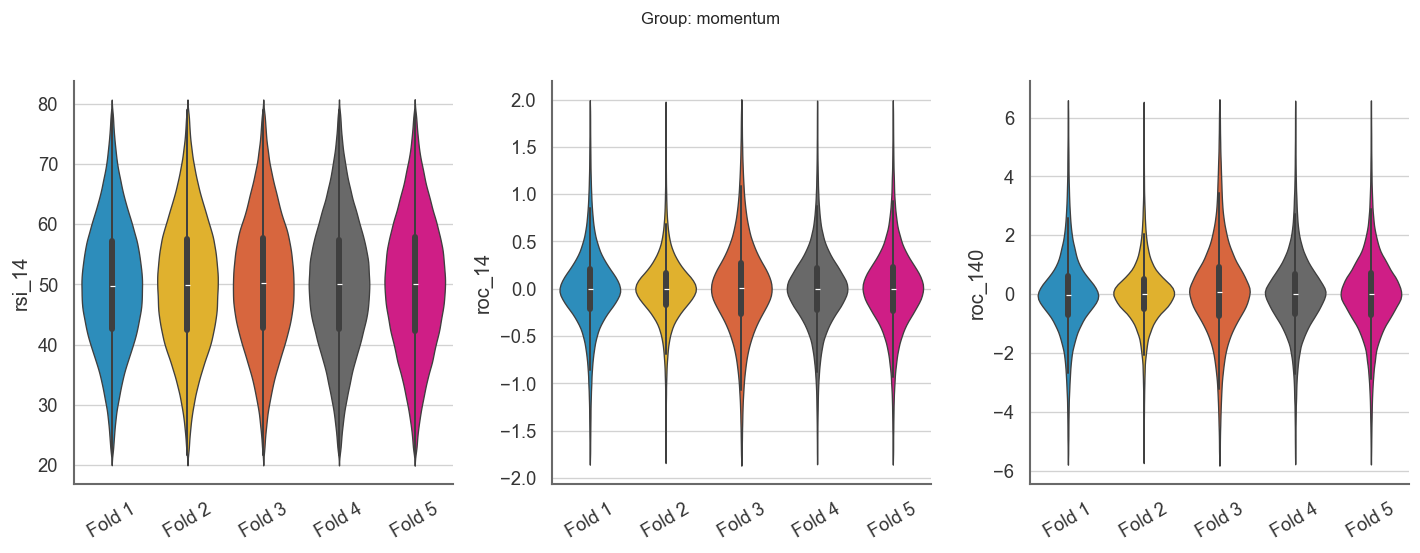

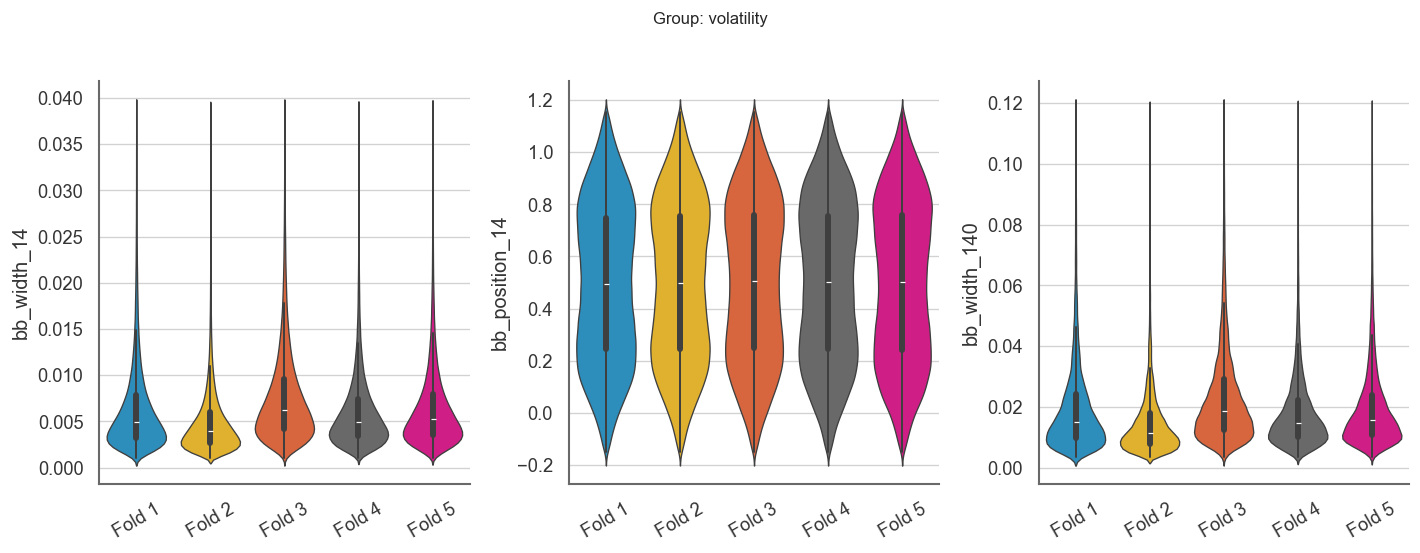

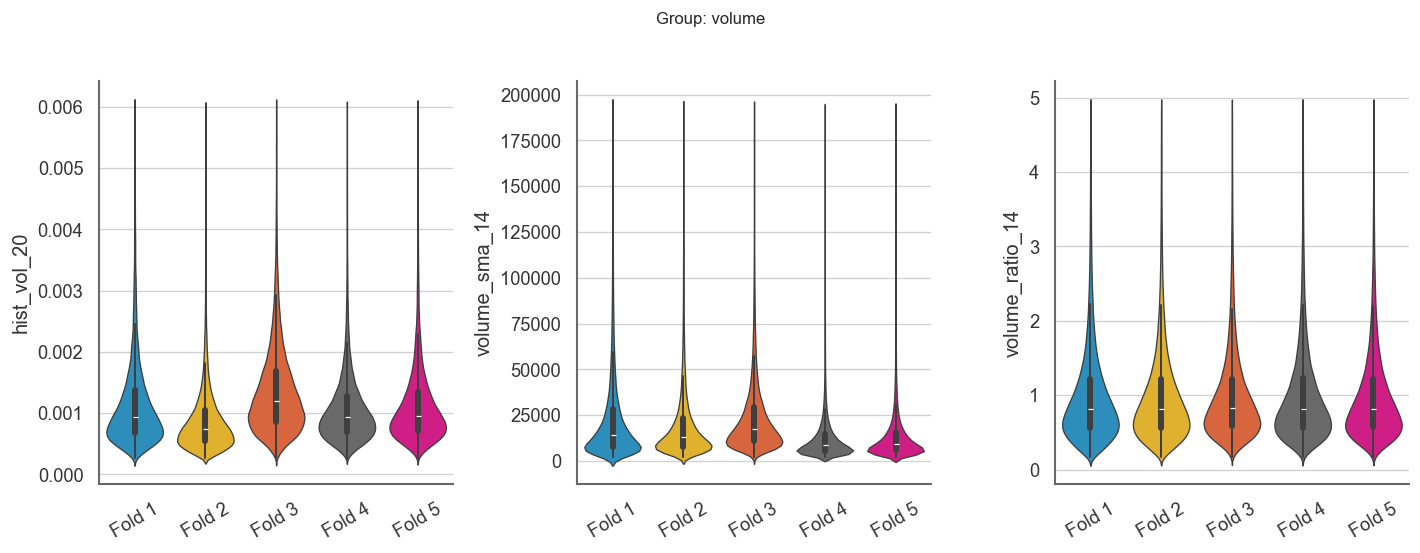

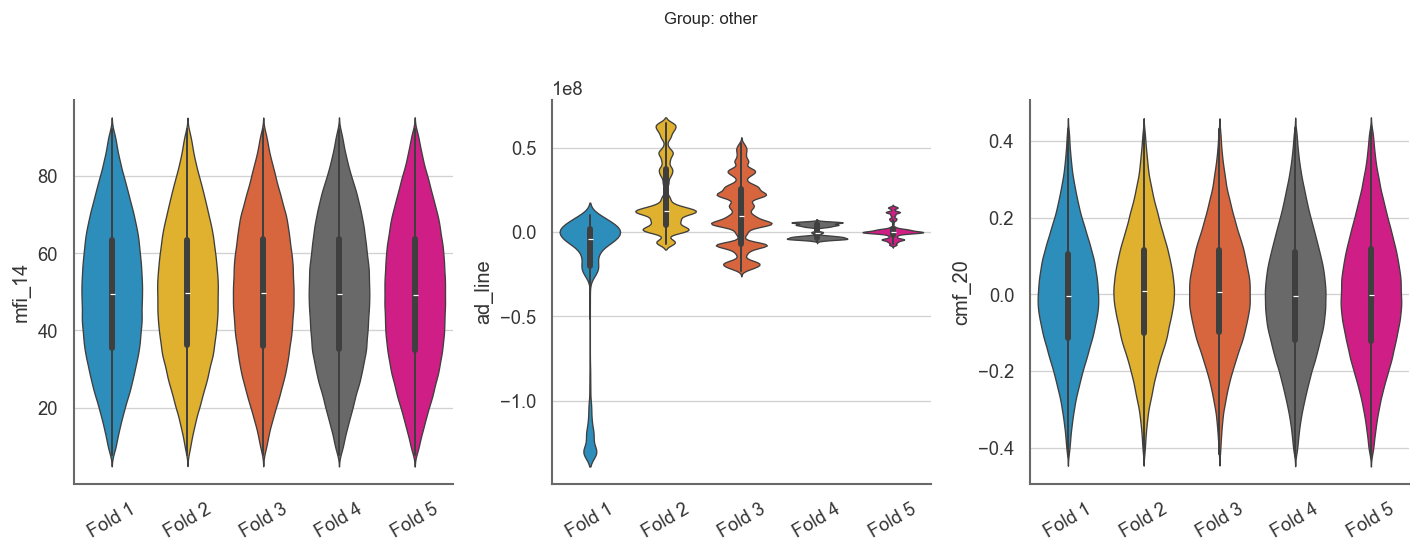

In [8]:
#| label: fig-feature-distributions
#| fig-cap: "Feature distributions per fold valid set — violin plots by group"
#| fig-subcap:
#|   - "Momentum features"
#|   - "Volume features"
#|   - "Volatility features"
#|   - "Other features"
#| layout-ncol: 1

violin_data = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .filter(pl.col("segment").is_in(VALID_SEGS))
    .select(["segment"] + REPR_FLAT)
    .collect()
    .to_pandas()
)
violin_data["fold"] = violin_data["segment"].apply(lambda s: f"Fold {seg_fold(s)}")

for grp, feats in REPR.items():
    avail = [f for f in feats if f in violin_data.columns]
    if not avail:
        continue
    fig, axes = plt.subplots(1, len(avail), figsize=(4 * len(avail), 4.5))
    if len(avail) == 1:
        axes = [axes]
    for ax, feat in zip(axes, avail):
        sub = violin_data[["fold", feat]].dropna()
        p001, p999 = sub[feat].quantile(0.005), sub[feat].quantile(0.995)
        sub = sub[(sub[feat] >= p001) & (sub[feat] <= p999)]
        sns.violinplot(data=sub, x="fold", y=feat, ax=ax,
                       palette=CQ_SEQUENCE, inner="box", linewidth=0.8)
        ax.set_xlabel("")
        ax.set_ylabel(feat.replace("feat_", ""))
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle(f"Group: {grp}", y=1.02, fontsize=10)
    plt.tight_layout()
    plt.show()

## 3. Fold összehasonlítás

### 3.1 Statisztikai összefoglaló per fold

**Purpose.** Ranks features by distribution drift magnitude across fold valid sets.

**Method.** Median per feature per fold valid set (loaded from parquet by segment). Drift metric: standard deviation of the 5 fold-medians. Top-20 most-drifting features reported.

**Interpretation.** High drift std on price-level features (OBV, VWAP) is expected. Drift on normalised ratio features (RSI, MACD) may indicate regime change.

**Action rule.** Document in Summary; not a standalone blocker.

In [9]:
#| label: tbl-drift-features
#| tbl-cap: "Top-20 features by median drift (std of fold-valid medians) across fold valid sets"

fold_medians: list[dict] = []
for seg in VALID_SEGS:
    fn = seg_fold(seg)
    chunk = (
        pl.scan_parquet(str(SAMPLE_PARQUET))
        .filter(pl.col("segment") == seg)
        .select(FEAT_COLS)
        .collect()
    )
    row: dict = {"fold": fn}
    for c in FEAT_COLS:
        vals = chunk[c].drop_nulls().to_numpy()
        row[c] = float(np.median(vals)) if len(vals) > 0 else np.nan
    fold_medians.append(row)

median_df = pd.DataFrame(fold_medians)
drift = (
    pd.DataFrame({"feature": FEAT_COLS,
                  "drift_std": [float(median_df[c].std()) for c in FEAT_COLS]})
    .sort_values("drift_std", ascending=False)
    .reset_index(drop=True)
)
display_analysis_table(drift.head(20))

feature,drift_std
feat_obv,9689400.526
feat_ad_line,7237842.790
feat_volume_sma_14,3742.436
feat_avg_trade_quote_30,438.037
feat_prev_session_high_dist,3.903
feat_cci_20,2.077
feat_prev_session_low_dist,1.837
feat_adx_neg_14,0.748
feat_stoch_d_14,0.743
feat_adx_pos_14,0.658


### 3.2 Distribution shift teszt

**Purpose.** Quantifies distribution shift between fold valid sets using the Kolmogorov–Smirnov statistic.

**Method.** Fold 1 valid is the reference. KS statistic computed per representative feature per fold pair. Heatmap: feature × fold.

**Interpretation.** High KS (> 0.15) on price-level features is expected and not a concern. High KS on normalised (ratio) features signals genuine regime shift.

**Action rule.** > 10% of normalised features KS > 0.15 on last fold vs fold 1 → flag in Summary.

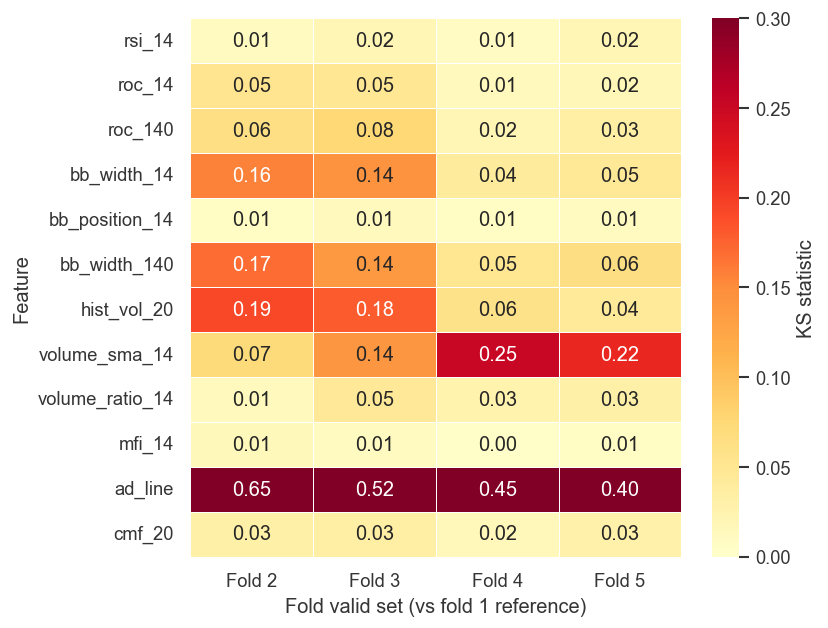

**Finding:** ⚠️ 10/48 cells (20.8%) exceed KS > 0.15 — notable distribution shift.

In [10]:
#| label: fig-ks-heatmap
#| fig-cap: "KS statistic heatmap: fold valid sets vs fold 1 valid (reference) — representative features"

ref_data = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .filter(pl.col("segment") == "fold_1_valid")
    .select(REPR_FLAT)
    .collect()
    .to_pandas()
)

ks_results: dict[str, dict] = {}
for seg in VALID_SEGS:
    fn = seg_fold(seg)
    if seg == "fold_1_valid":
        continue
    comp = (
        pl.scan_parquet(str(SAMPLE_PARQUET))
        .filter(pl.col("segment") == seg)
        .select(REPR_FLAT)
        .collect()
        .to_pandas()
    )
    col_key = f"Fold {fn}"
    ks_results[col_key] = {}
    for feat in REPR_FLAT:
        a = ref_data[feat].dropna().values
        b = comp[feat].dropna().values
        ks_results[col_key][feat] = float(stats.ks_2samp(a, b)[0]) if len(a) > 0 and len(b) > 0 else np.nan

ks_df = pd.DataFrame(ks_results, index=REPR_FLAT)
ks_df.index = [i.replace("feat_", "") for i in ks_df.index]

fig, ax = plt.subplots(figsize=(7, max(4, len(REPR_FLAT) * 0.45)))
sns.heatmap(ks_df, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=0.3,
            linewidths=0.3, ax=ax, cbar_kws={"label": "KS statistic"})
ax.set_xlabel("Fold valid set (vs fold 1 reference)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

high_ks = int((ks_df > 0.15).sum().sum())
total   = int(ks_df.notna().sum().sum())
pct     = high_ks / total * 100 if total > 0 else 0
if pct < 10:
    display(Markdown(f"**Finding:** ✅ {high_ks}/{total} cells ({pct:.1f}%) exceed KS > 0.15 — within acceptable range."))
else:
    display(Markdown(f"**Finding:** ⚠️ {high_ks}/{total} cells ({pct:.1f}%) exceed KS > 0.15 — notable distribution shift."))

## 4. Feature korrelációk

### 4.1 Teljes korrelációs mátrix

**Purpose.** Reveals redundancy and multicollinearity structure across all features on the training data.

**Method.** Pearson correlation matrix on a 50,000-row random sample from `fold_5_train` (the largest training segment, approximating the union of all fold trains). Ward-linkage clustered heatmap. Cells with |r| > 0.9 annotated in section 4.2.

**Interpretation.** LightGBM is robust to multicollinearity, but |r| > 0.9 pairs may cause feature-importance instability.

**Action rule.** Report number of pairs > 0.9; no standalone blocker.

In [11]:
# Use lazy head(50_000) — Polars pushes limit to parquet reader, avoiding full load
train_sample = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .filter(pl.col("segment") == "fold_5_train")
    .select(FEAT_COLS)
    .head(50_000)
    .collect()
    .drop_nulls()
)
_n_train = train_sample.height
train_np = train_sample.to_numpy()
print(f"Train sample: {train_np.shape[0]:,} rows × {train_np.shape[1]} features")
CORR_MATRIX = np.corrcoef(train_np.T)
corr_df = pd.DataFrame(CORR_MATRIX, index=FEAT_COLS, columns=FEAT_COLS)

Train sample: 49,626 rows × 208 features


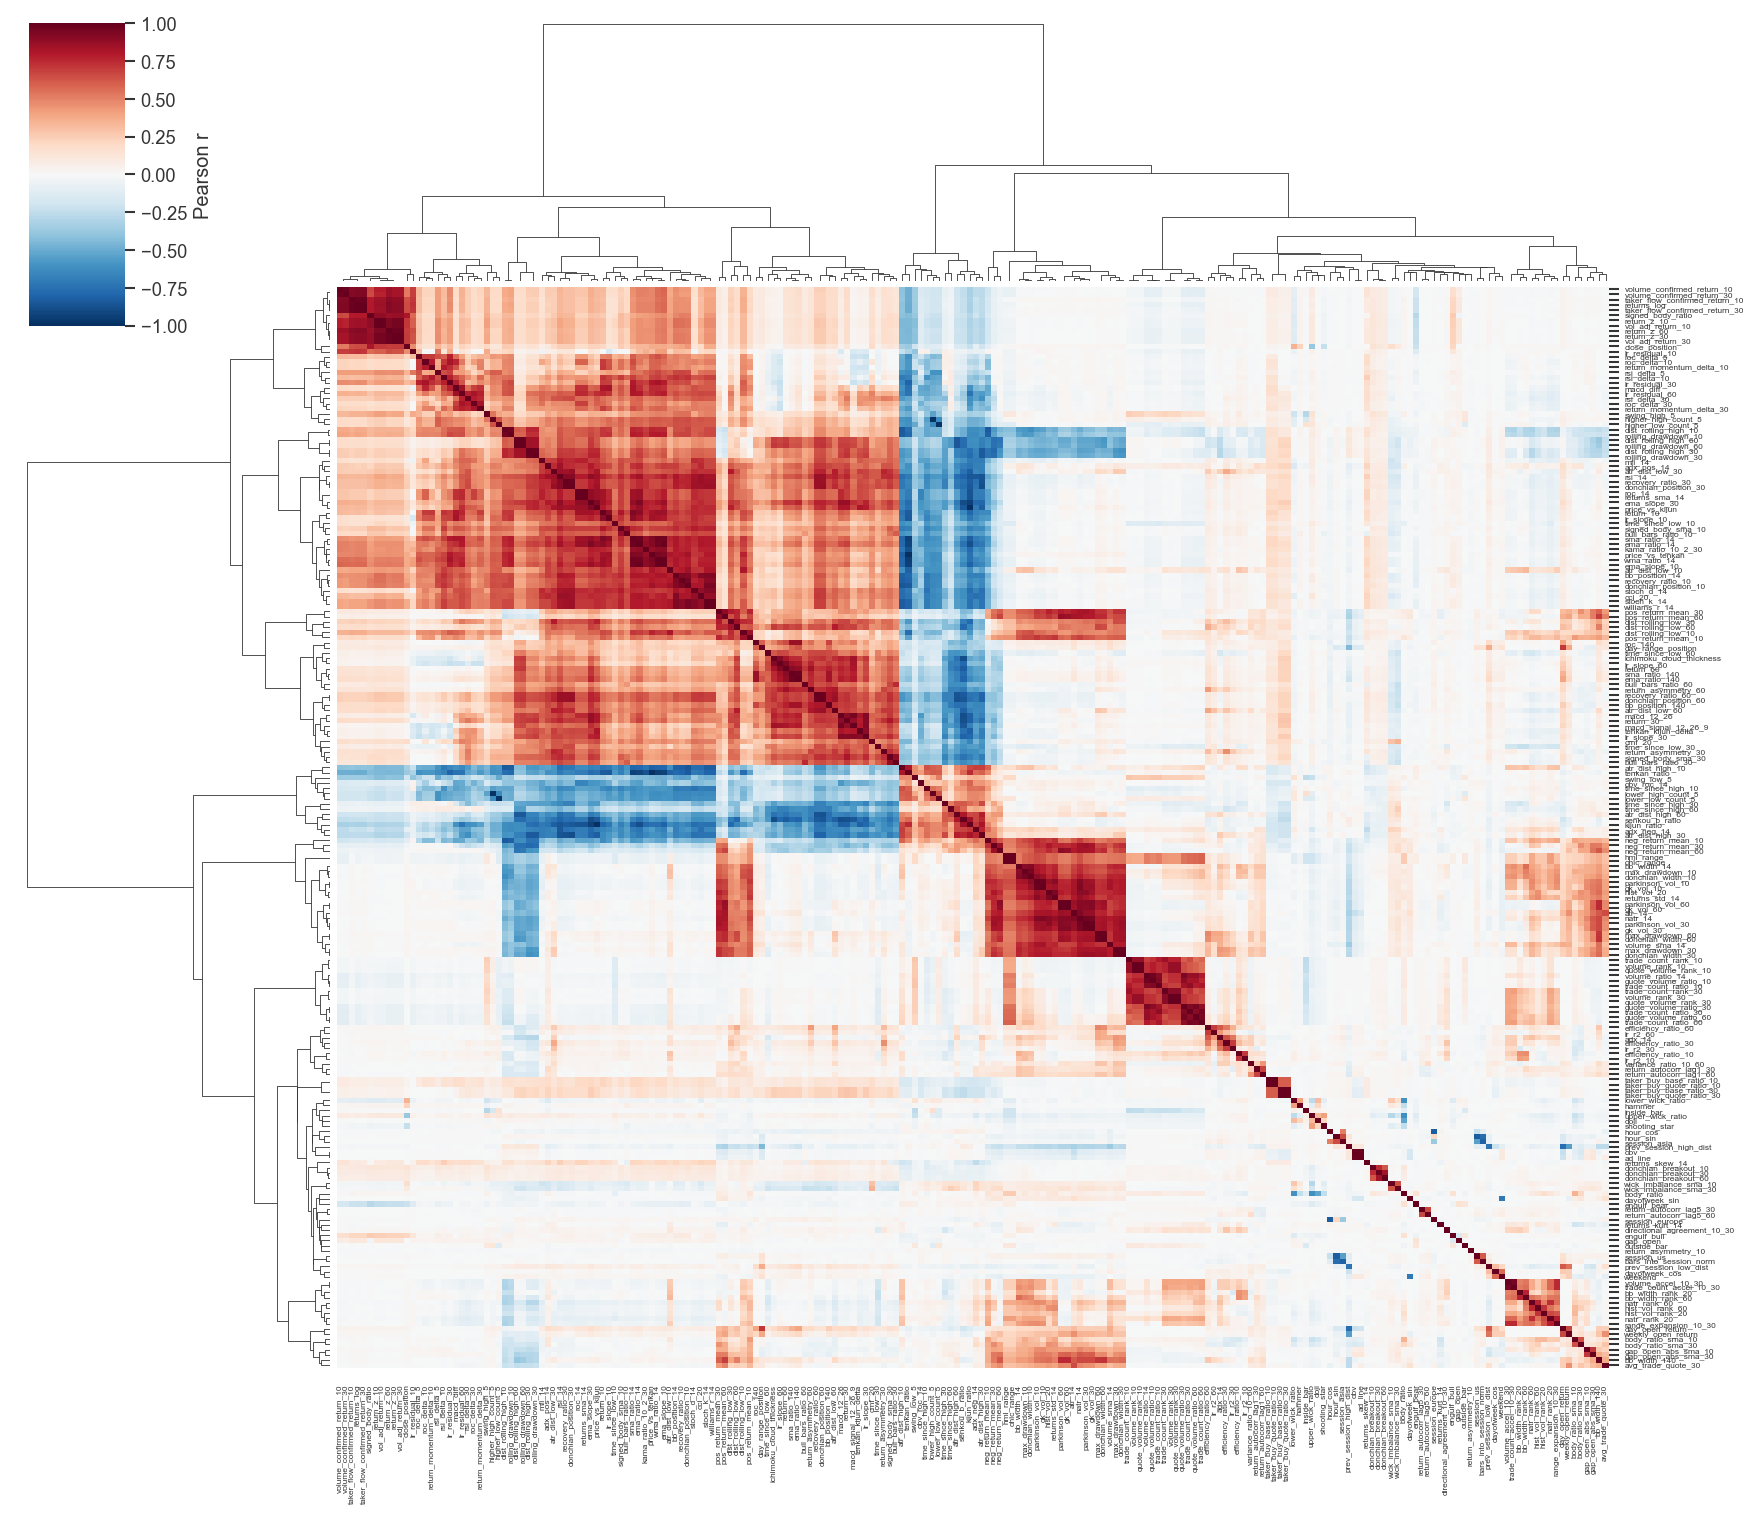

In [12]:
#| label: fig-correlation-heatmap
#| fig-cap: "Clustered Pearson correlation matrix — all features on fold_5_train sample (50k rows)"
#| fig-alt: "Clustered heatmap of Pearson correlations among all features."

short = [c.replace("feat_", "") for c in FEAT_COLS]
corr_short = corr_df.copy()
corr_short.index = short
corr_short.columns = short

g = sns.clustermap(
    corr_short, method="ward", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    figsize=(16, 14), xticklabels=True, yticklabels=True,
    cbar_kws={"label": "Pearson r"}
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), size=5, rotation=90)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), size=5, rotation=0)
plt.show()

### 4.2 Magas korrelációjú feature párok

**Purpose.** Lists all feature pairs with absolute Pearson correlation > 0.90.

**Method.** Upper triangle of the correlation matrix filtered to |r| > 0.90, sorted descending.

**Interpretation.** Near-redundant pairs are safe for LightGBM but may cause feature-importance instability.

**Action rule.** > 30 pairs > 0.90 → flag for Modeling Agent to consider feature pruning.

In [13]:
#| label: tbl-high-corr-pairs
#| tbl-cap: "Feature pairs with absolute Pearson correlation > 0.90 (top 30 shown)"

n = len(FEAT_COLS)
pairs = [
    {"feature_a": FEAT_COLS[i], "feature_b": FEAT_COLS[j],
     "pearson_r": round(float(CORR_MATRIX[i, j]), 4)}
    for i in range(n) for j in range(i + 1, n)
    if abs(CORR_MATRIX[i, j]) > 0.90
]
pairs_df = (pd.DataFrame(pairs)
            .sort_values("pearson_r", ascending=False, key=abs)
            .reset_index(drop=True))
print(f"Pairs |r| > 0.90: {len(pairs_df)}")
display_analysis_table(pairs_df.head(30))

if len(pairs_df) <= 30:
    display(Markdown(f"**Finding:** ✅ {len(pairs_df)} pairs exceed |r| > 0.90 — manageable redundancy for LightGBM."))
else:
    display(Markdown(f"**Finding:** ⚠️ {len(pairs_df)} pairs exceed |r| > 0.90 — consider feature pruning."))

Pairs |r| > 0.90: 116


feature_a,feature_b,pearson_r
feat_roc_14,feat_returns_sma_14,1.000
feat_stoch_k_14,feat_williams_r_14,1.000
feat_taker_buy_base_ratio_30,feat_taker_buy_quote_ratio_30,1.000
feat_hml_range,feat_ohlc_range,1.000
feat_return_z_10,feat_vol_adj_return_10,1.000
feat_tenkan_ratio,feat_price_vs_tenkan,-1.000
feat_kijun_ratio,feat_price_vs_kijun,-1.000
feat_return_z_30,feat_vol_adj_return_30,1.000
feat_taker_buy_base_ratio_10,feat_taker_buy_quote_ratio_10,1.000
feat_volume_rank_30,feat_quote_volume_rank_30,1.000


**Finding:** ⚠️ 116 pairs exceed |r| > 0.90 — consider feature pruning.

### 4.3 Feature–target korreláció

**Purpose.** Identifies features with the strongest monotonic relationship to each target.

**Method.** Spearman correlation between each `feat_*` column and both binary targets on the 50k train sample. Top-20 per target as horizontal bar charts.

**Interpretation.** High absolute Spearman (> 0.10) indicates predictive relevance. Low overall Spearman is normal for binary targets.

**Action rule.** All features at |ρ| < 0.002 → raise a todo ticket for the Modeling Agent.

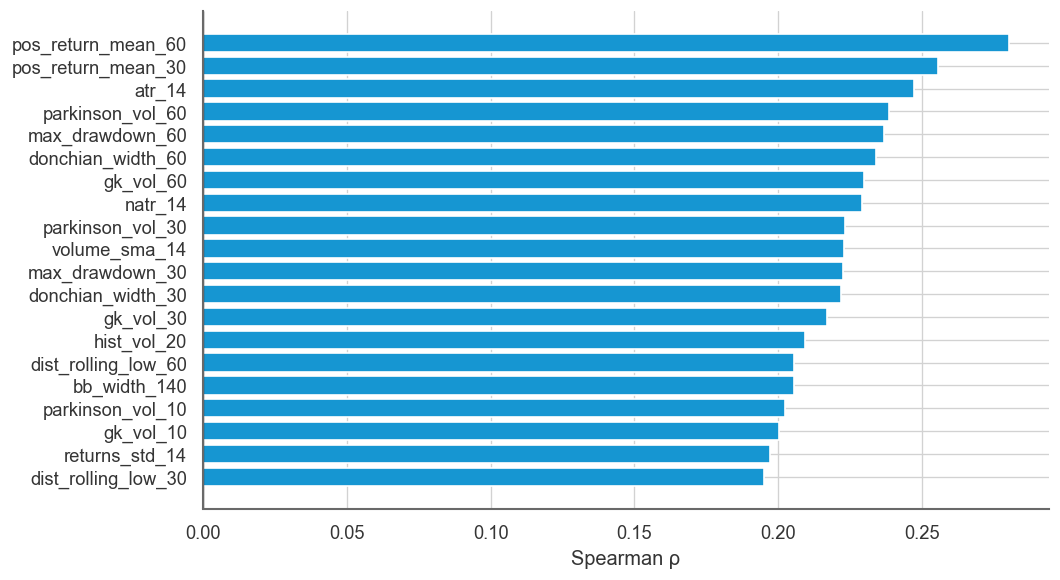

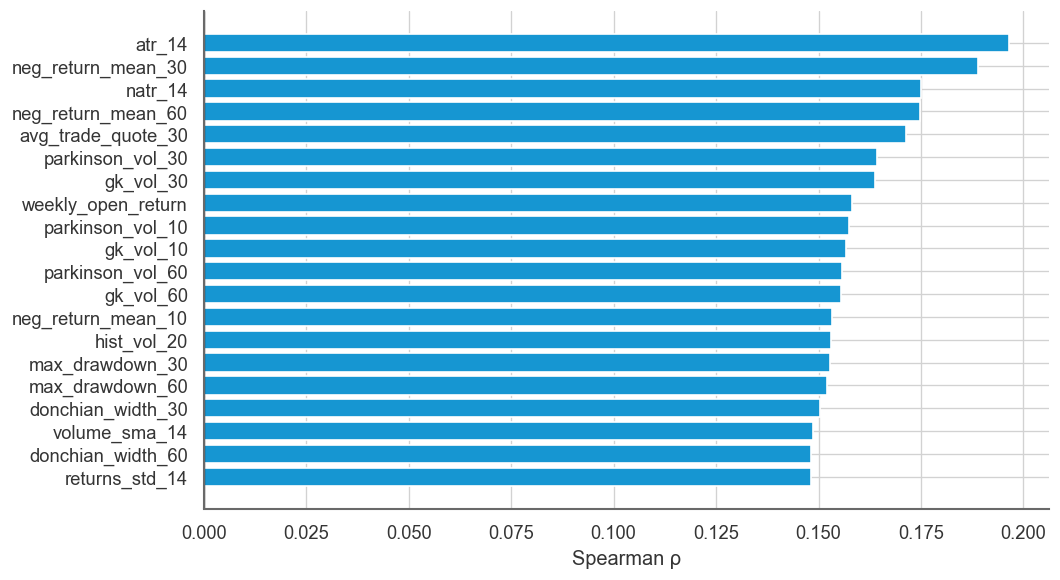

In [14]:
#| label: fig-spearman-corr
#| fig-cap: "Spearman correlation of top-20 features with each target (fold_5_train sample)"
#| fig-subcap:
#|   - "Long target (trg_l_fw60_q90)"
#|   - "Short target (trg_s_fw60_q10)"
#| layout-ncol: 1

train_w_tgt = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .filter(pl.col("segment") == "fold_5_train")
    .select(FEAT_COLS + TARGETS)
    .head(50_000)
    .collect()
    .to_pandas()
)

for target in TARGETS:
    tgt_vals = train_w_tgt[target].dropna().astype(float)
    sp_rows = []
    for feat in FEAT_COLS:
        feat_vals = train_w_tgt[feat]
        idx = tgt_vals.index.intersection(feat_vals.dropna().index)
        if len(idx) < 100:
            continue
        rho, _ = stats.spearmanr(feat_vals.loc[idx].values, tgt_vals.loc[idx].values)
        sp_rows.append({"feature": feat, "spearman_r": rho})
    sp_df = (pd.DataFrame(sp_rows)
             .sort_values("spearman_r", key=abs, ascending=False)
             .head(20))
    sp_df["feat_short"] = sp_df["feature"].str.replace("feat_", "", regex=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = [CQ_COLORS["blue"] if r >= 0 else CQ_COLORS["red"] for r in sp_df["spearman_r"]]
    ax.barh(sp_df["feat_short"], sp_df["spearman_r"], color=colors)
    ax.axvline(0, color=CQ_COLORS["gray_dark"], linewidth=0.8)
    ax.set_xlabel("Spearman ρ")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 5. Feature csoport korrelációk

### 5.1 Csoporton belüli korrelációk

**Purpose.** Shows internal correlation structure within each semantic feature group.

**Method.** Pearson correlation heatmap per group using the 50k train sample.

**Interpretation.** Within-group high correlations are expected (e.g. RSI-14 and Stoch-14 both measure momentum). Not a concern unless the entire group is one cluster.

**Action rule.** Entire group at |r| > 0.95 uniformly → flag for potential consolidation.

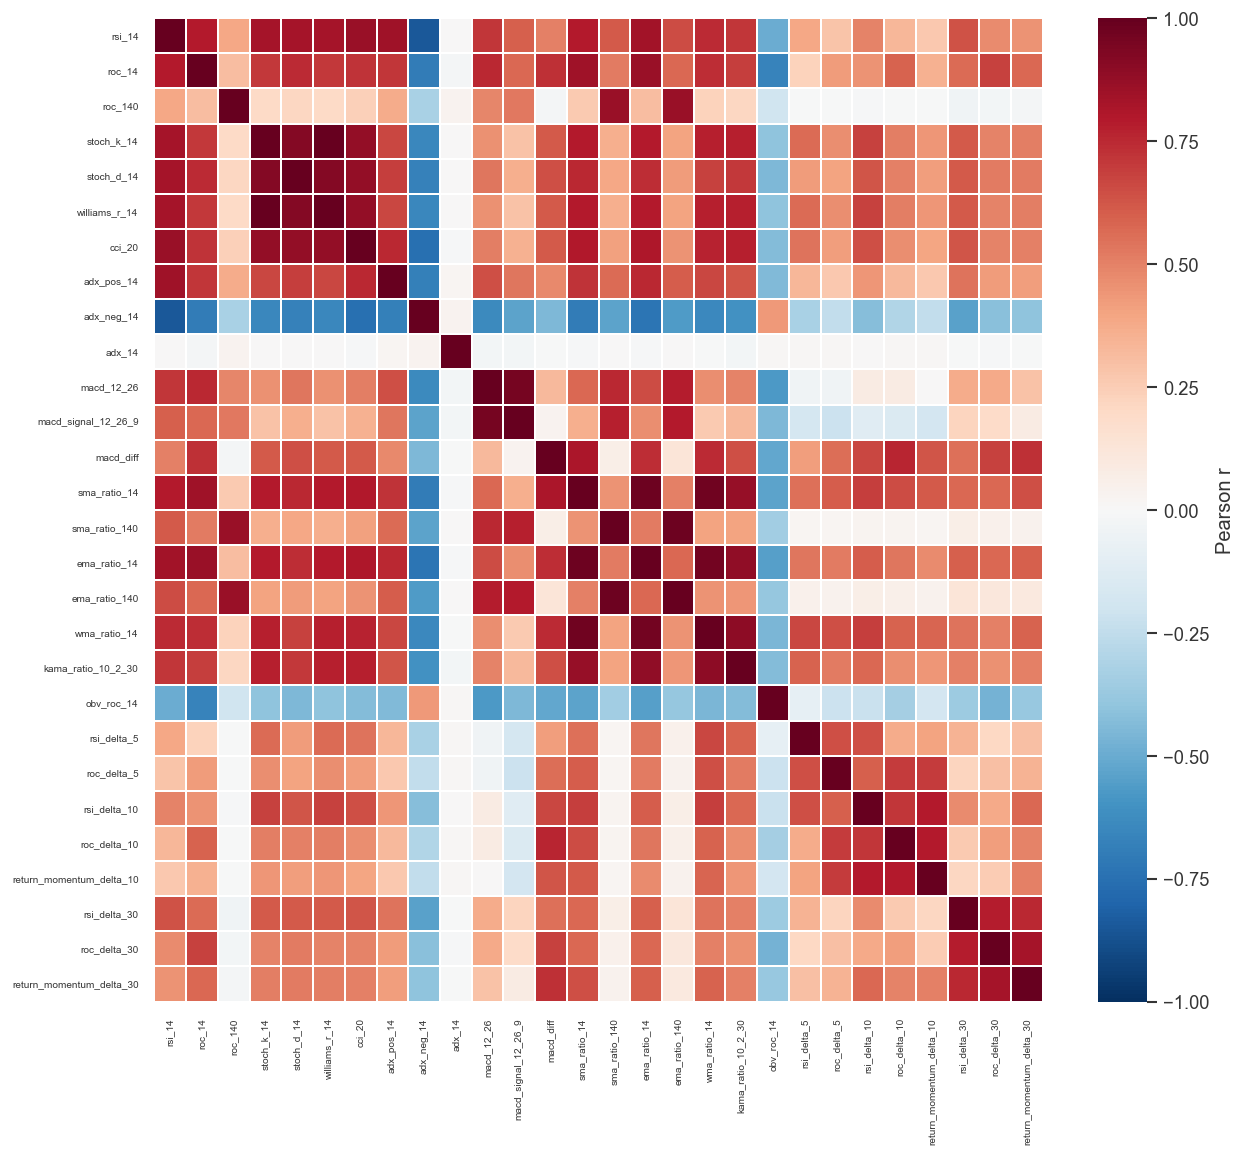

**Group momentum:** 28 features, average pairwise |r| = 0.464

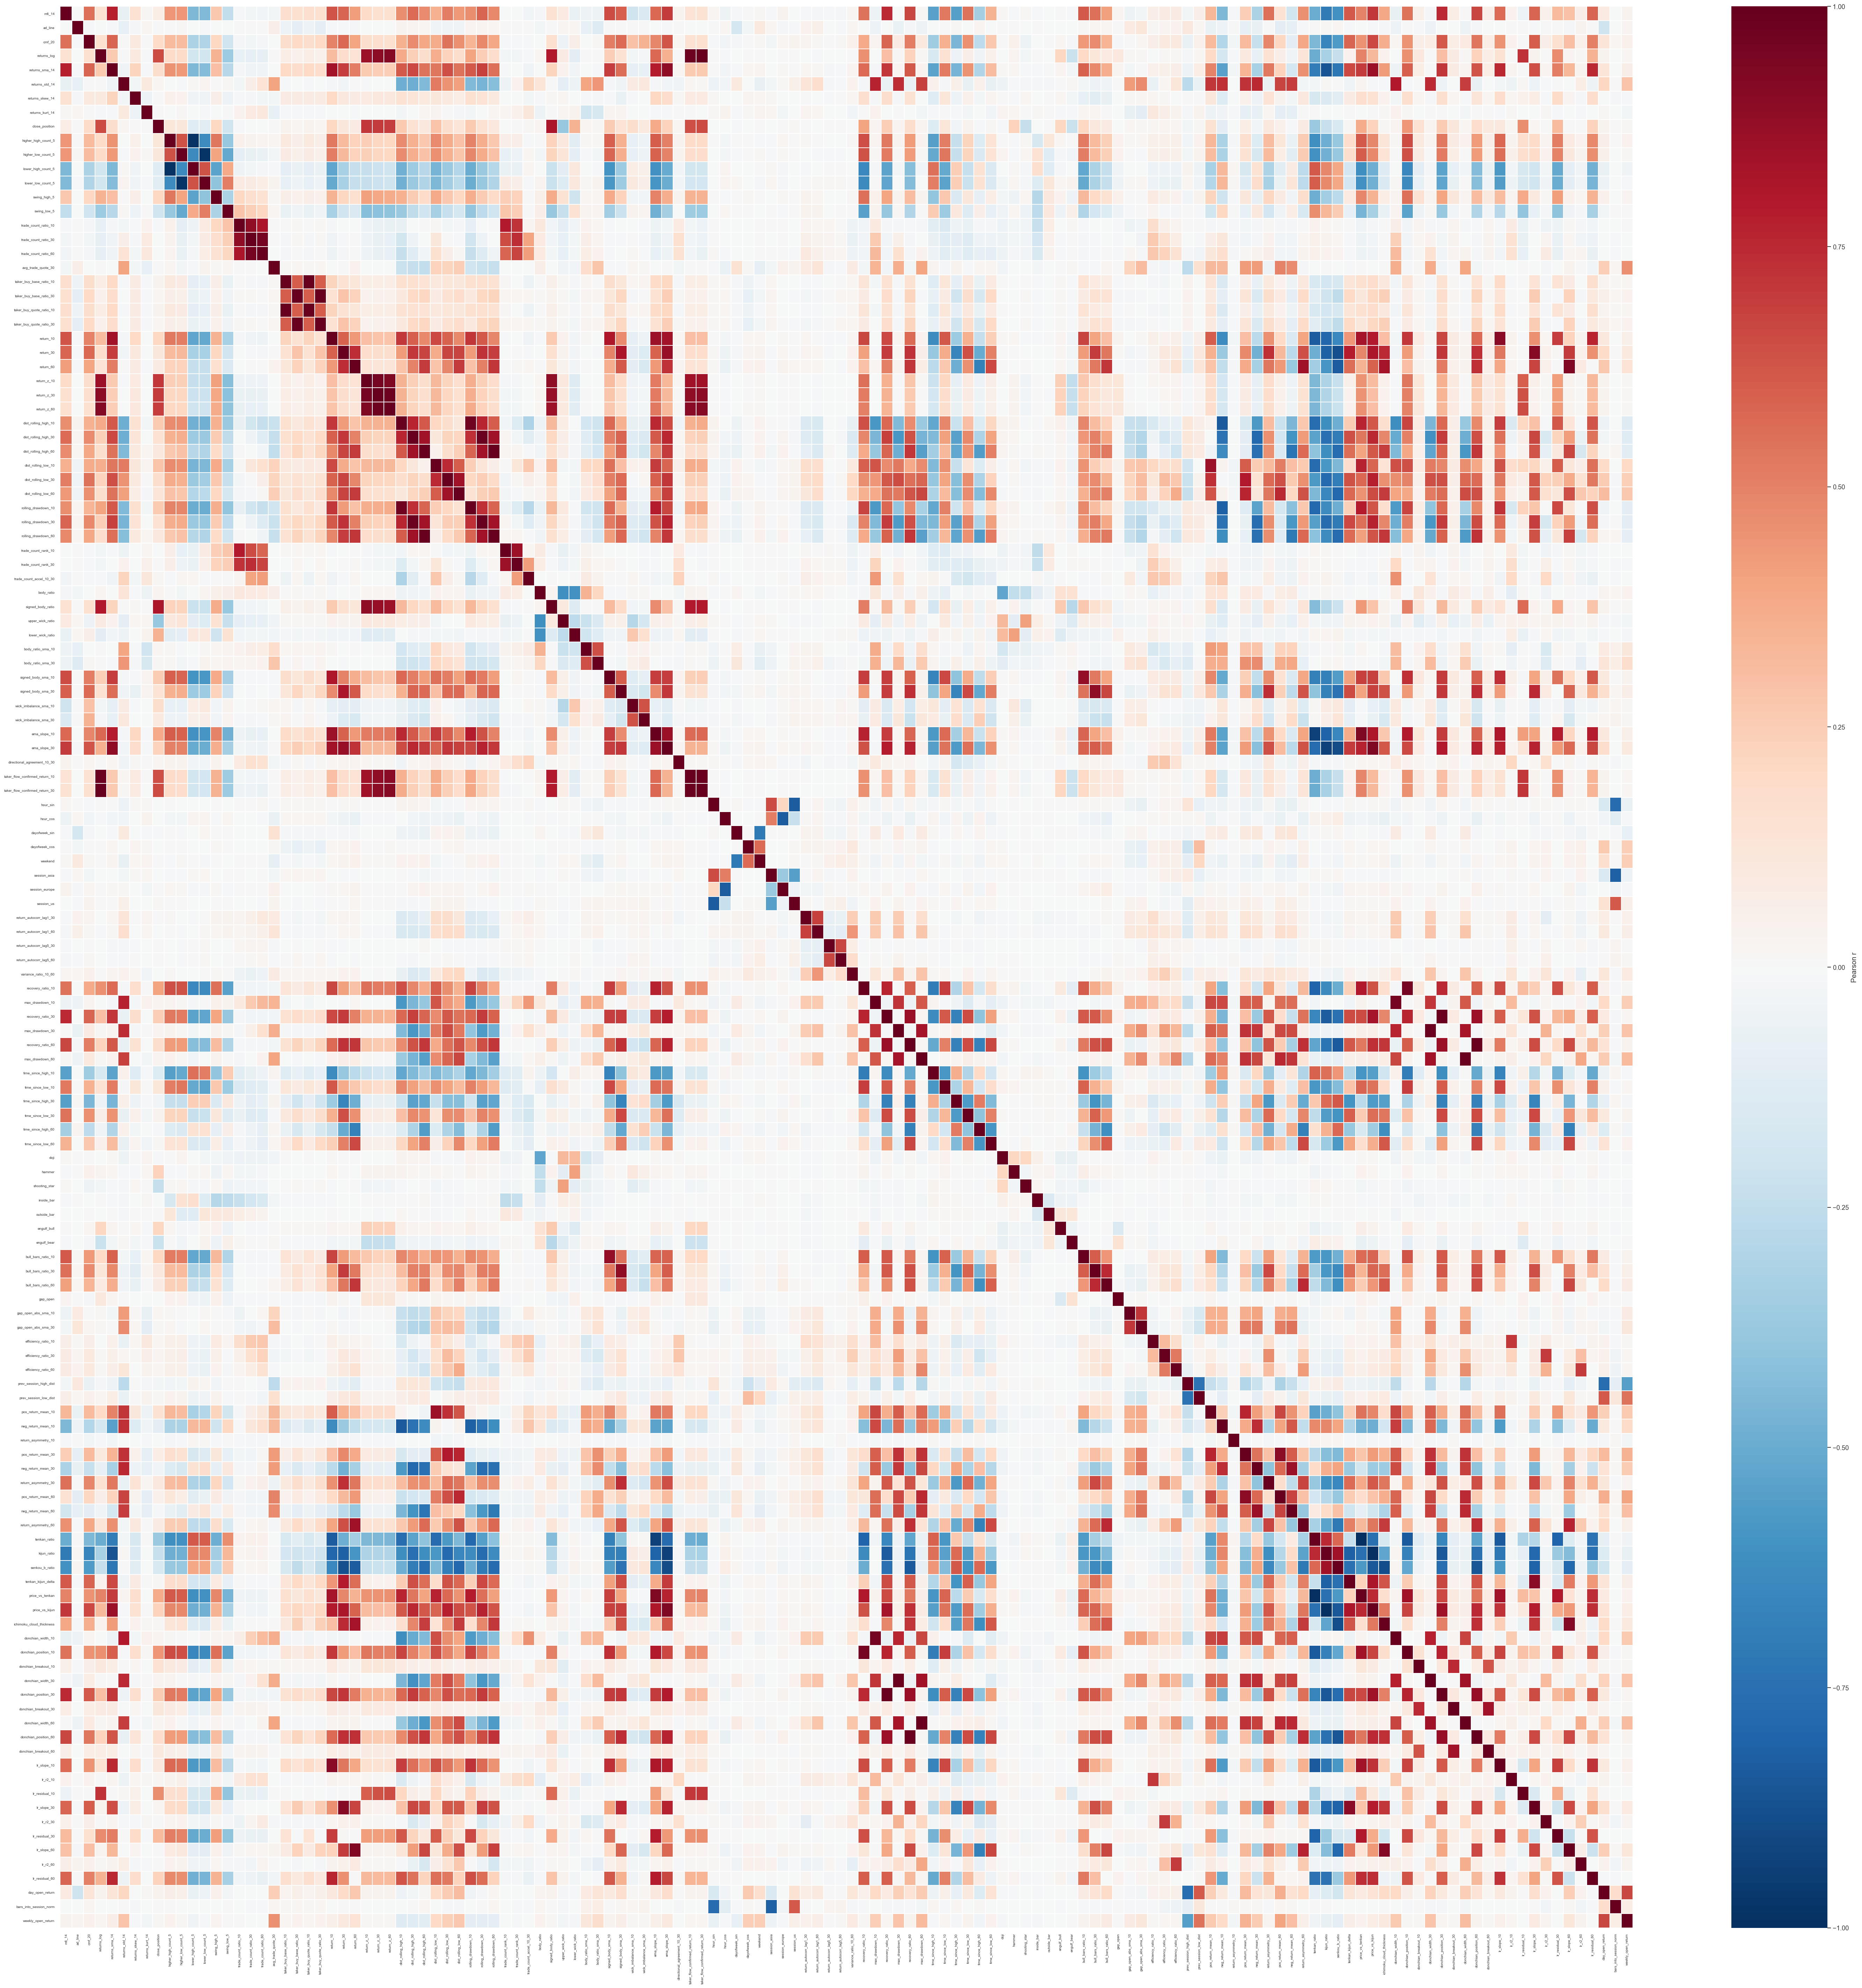

**Group other:** 136 features, average pairwise |r| = 0.151

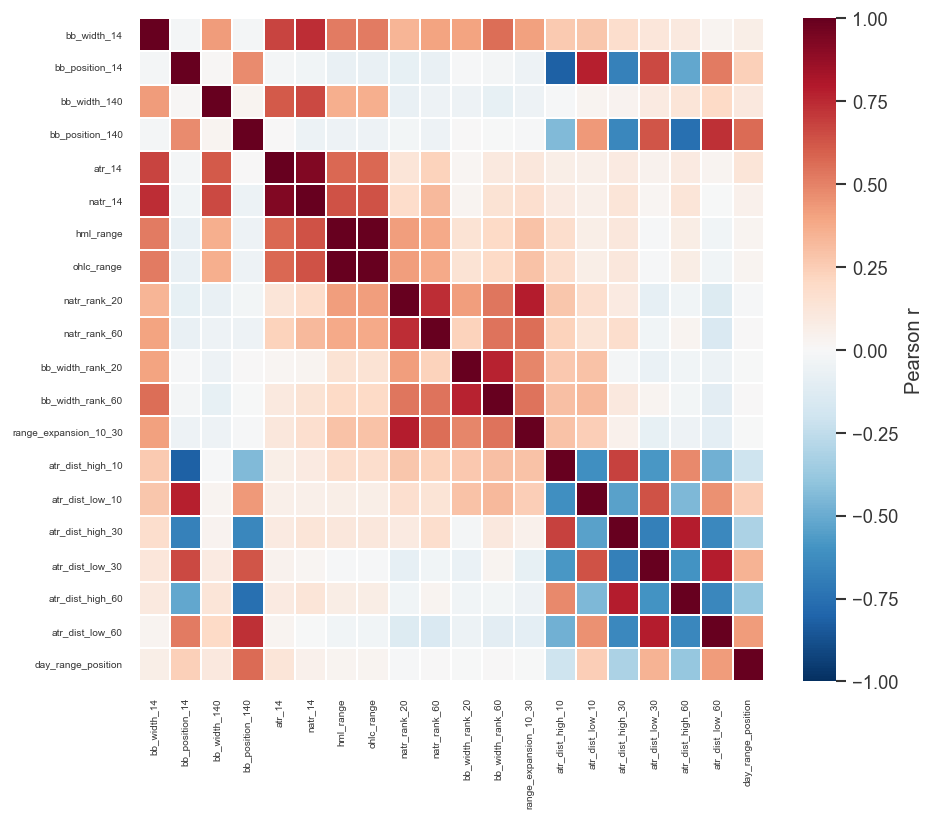

**Group volatility:** 20 features, average pairwise |r| = 0.262

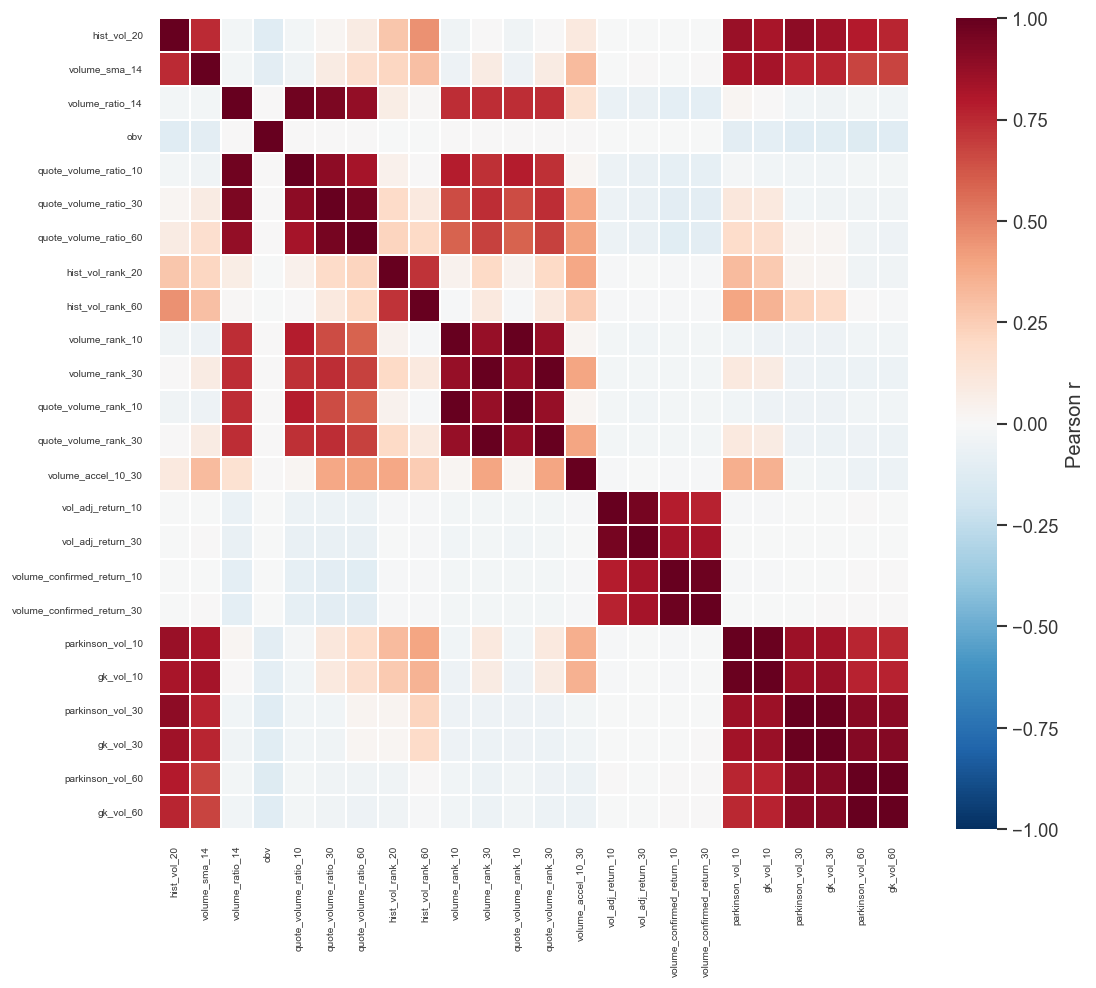

**Group volume:** 24 features, average pairwise |r| = 0.240

In [15]:
#| label: fig-within-group-corr
#| fig-cap: "Within-group Pearson correlation heatmaps (fold_5_train sample)"
#| fig-subcap:
#|   - "Momentum"
#|   - "Volume"
#|   - "Volatility"
#|   - "Other"
#| layout-ncol: 1

train_pd = pd.DataFrame(train_np, columns=FEAT_COLS)

for grp, cols in sorted(GROUPS.items()):
    avail = [c for c in cols if c in train_pd.columns]
    if len(avail) < 2:
        continue
    grp_corr = train_pd[avail].corr(method="pearson")
    short_idx = [c.replace("feat_", "") for c in avail]
    grp_corr.index = short_idx
    grp_corr.columns = short_idx

    fig_sz = max(5, len(avail) * 0.35)
    fig, ax = plt.subplots(figsize=(fig_sz + 1, fig_sz))
    sns.heatmap(grp_corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                ax=ax, linewidths=0.2, cbar_kws={"label": "Pearson r"})
    ax.set_xticklabels(ax.get_xticklabels(), size=6, rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), size=6, rotation=0)
    plt.tight_layout()
    plt.show()

    upper = grp_corr.values
    mask  = np.triu(np.ones_like(upper, dtype=bool), k=1)
    avg_r = float(np.abs(upper[mask]).mean()) if mask.sum() > 0 else np.nan
    display(Markdown(f"**Group {grp}:** {len(avail)} features, average pairwise |r| = {avg_r:.3f}"))

### 5.2 Csoportközi korrelációk

**Purpose.** Measures cross-group linear relationships to detect unexpected inter-family dependencies.

**Method.** A simple mean of z-scored features within each group produces one composite feature per group. The 4×4 Pearson correlation matrix of these composites is reported.

**Interpretation.** Cross-group correlations > 0.5 suggest overlapping information between families.

**Action rule.** Inter-group |r| > 0.80 → flag for review.

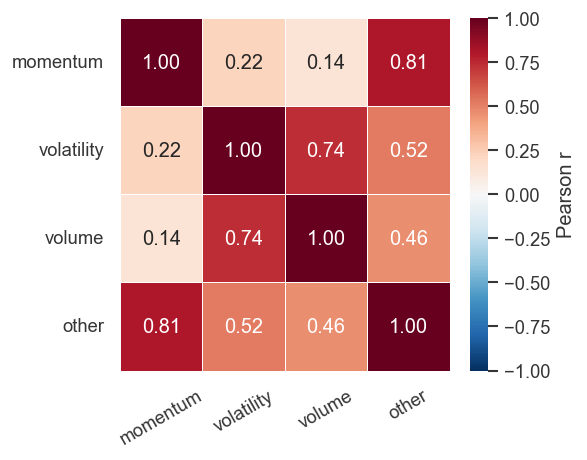

**Finding:** ⚠️ Maximum cross-group |r| = 0.812 — potential feature overlap between groups.

In [16]:
#| label: fig-cross-group-corr
#| fig-cap: "Cross-group correlation matrix (z-scored group composite features from fold_5_train sample)"

composites: dict[str, np.ndarray] = {}
for grp, cols in GROUPS.items():
    avail = [c for c in cols if c in train_pd.columns]
    if not avail:
        continue
    arr = train_pd[avail].fillna(0).values.astype(float)
    mu  = arr.mean(axis=0, keepdims=True)
    sd  = arr.std(axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    scaled = (arr - mu) / sd
    composites[grp] = scaled.mean(axis=1)

comp_df   = pd.DataFrame(composites)
cross_corr = comp_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, cbar_kws={"label": "Pearson r"})
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

mask = np.triu(np.ones(cross_corr.shape, dtype=bool), k=1)
max_cross = float(cross_corr.values[mask].max()) if mask.sum() > 0 else 0.0
if max_cross <= 0.80:
    display(Markdown(f"**Finding:** ✅ Maximum cross-group |r| = {max_cross:.3f} — no strong inter-family redundancy."))
else:
    display(Markdown(f"**Finding:** ⚠️ Maximum cross-group |r| = {max_cross:.3f} — potential feature overlap between groups."))

## 6. Test set hasonlóság a CV-hez

### 6.1 Feature eloszlás — test vs valid foldok

**Purpose.** Checks whether the test set's feature distributions lie within the range established by the CV valid folds.

**Method.** KDE overlay plot for the representative features (~12). Each fold valid set plus the test set as a separate curve.

**Interpretation.** Healthy: test KDE overlaps substantially with at least some valid fold KDEs. Risky: test is shifted away from all folds.

**Action rule.** Test is an outlier on > 3 of the representative features → flag distribution shift risk in Summary.

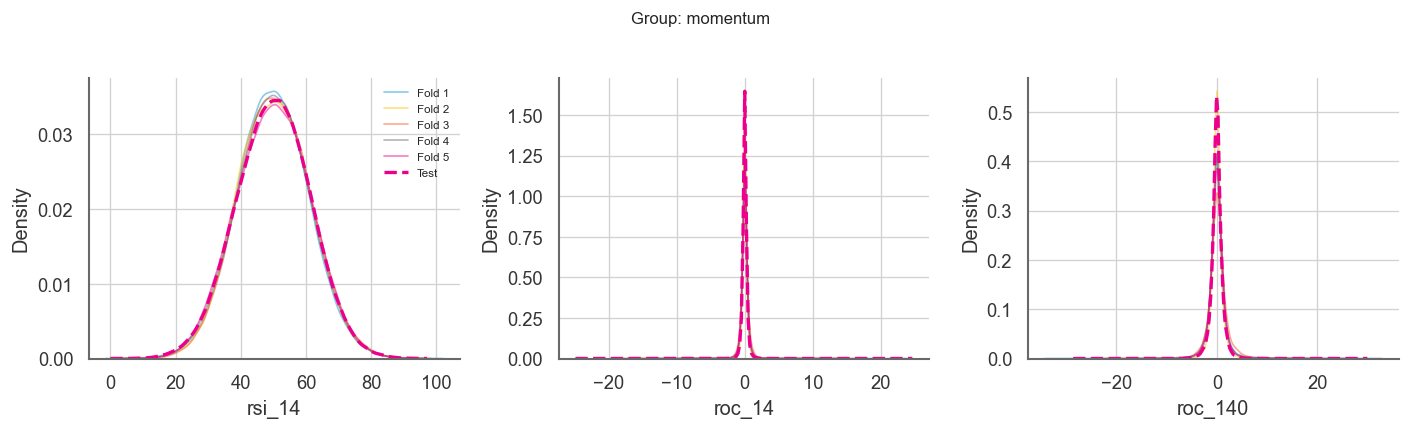

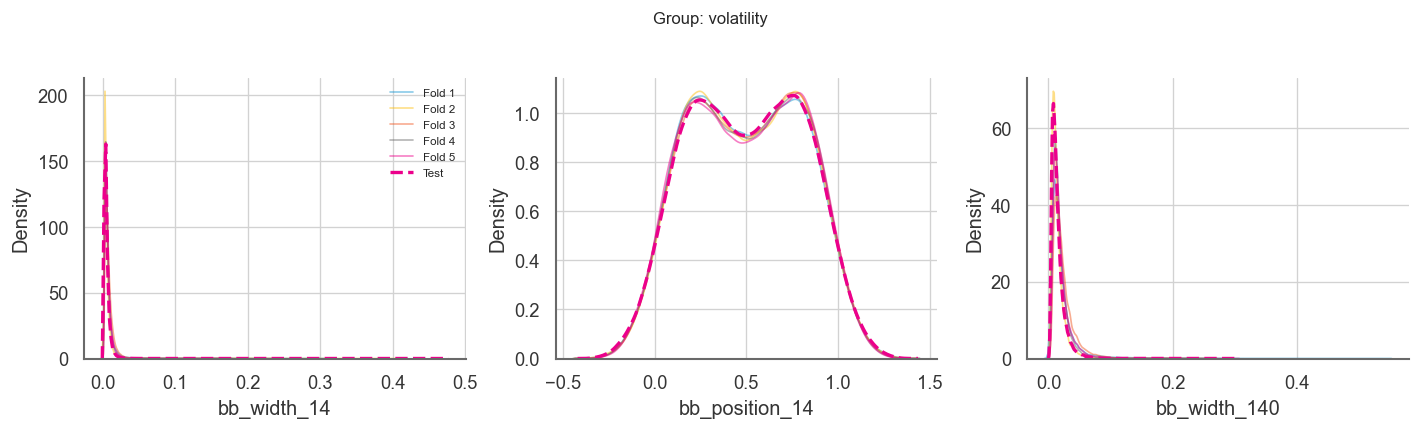

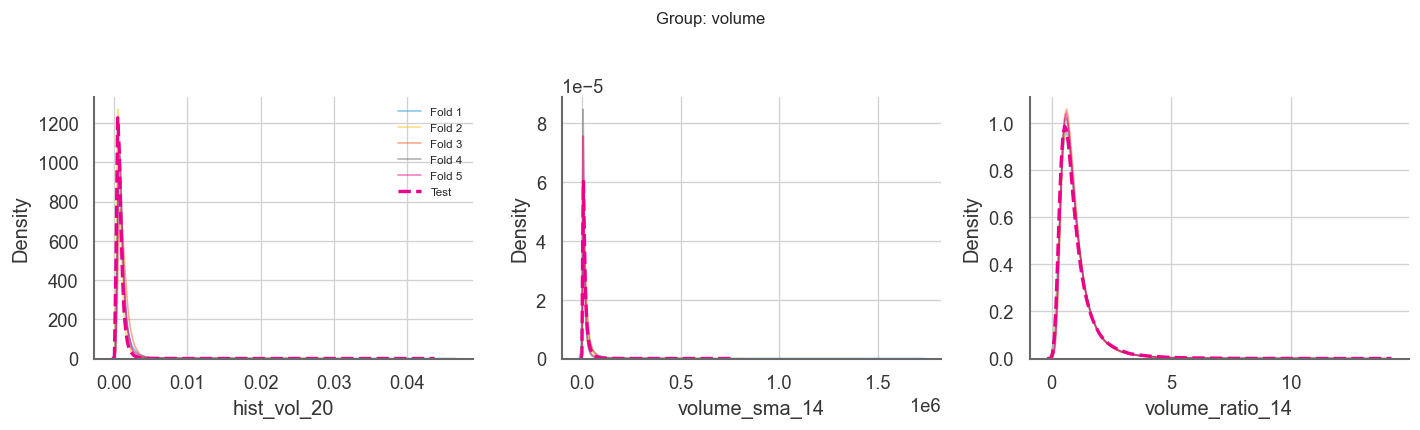

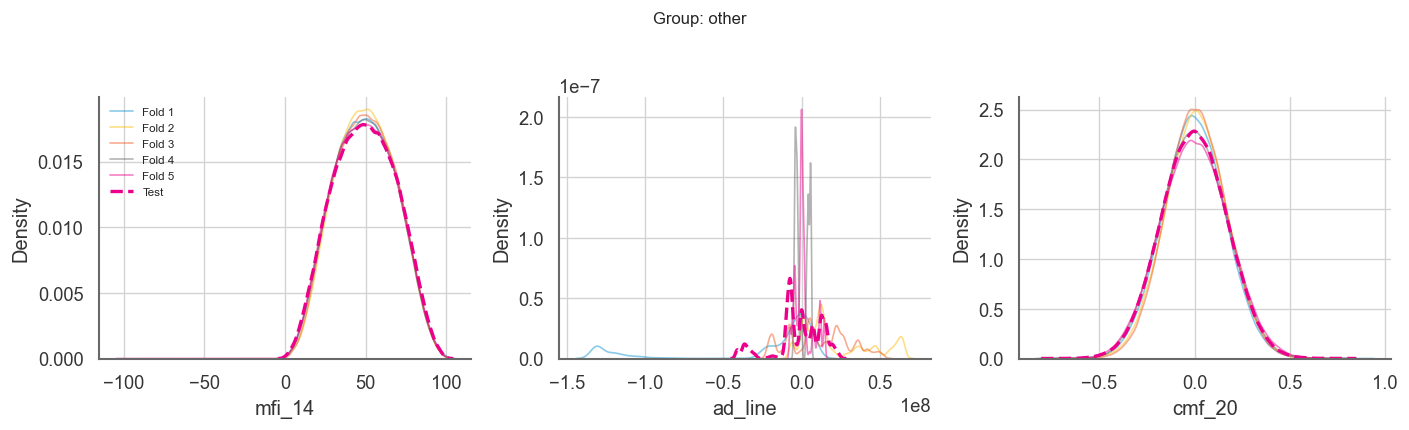

In [17]:
#| label: fig-test-vs-valid-kde
#| fig-cap: "KDE overlay: test set vs fold valid sets for representative features"
#| fig-subcap:
#|   - "Momentum features"
#|   - "Volume features"
#|   - "Volatility features"
#|   - "Other features"
#| layout-ncol: 1

test_data = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .filter(pl.col("segment") == "test")
    .select(REPR_FLAT)
    .collect()
    .to_pandas()
)

valid_dfs = {
    f"Fold {seg_fold(seg)}": (
        pl.scan_parquet(str(SAMPLE_PARQUET))
        .filter(pl.col("segment") == seg)
        .select(REPR_FLAT)
        .collect()
        .to_pandas()
    )
    for seg in VALID_SEGS
}

for grp, feats in REPR.items():
    avail = [f for f in feats if f in REPR_FLAT]
    if not avail:
        continue
    fig, axes = plt.subplots(1, len(avail), figsize=(4 * len(avail), 3.5))
    if len(avail) == 1:
        axes = [axes]
    for ax, feat in zip(axes, avail):
        for i, (fold_label, fold_df) in enumerate(valid_dfs.items()):
            vals = fold_df[feat].dropna()
            if len(vals) > 50:
                sns.kdeplot(vals, ax=ax, color=CQ_SEQUENCE[i % len(CQ_SEQUENCE)],
                            alpha=0.5, linewidth=1,
                            label=fold_label if feat == avail[0] else "_")
        test_vals = test_data[feat].dropna()
        if len(test_vals) > 50:
            sns.kdeplot(test_vals, ax=ax, color=CQ_COLORS["red"],
                        linewidth=2, linestyle="--",
                        label="Test" if feat == avail[0] else "_")
        ax.set_xlabel(feat.replace("feat_", ""))
        ax.set_ylabel("Density")
        if feat == avail[0]:
            ax.legend(fontsize=7)
    plt.suptitle(f"Group: {grp}", y=1.02, fontsize=10)
    plt.tight_layout()
    plt.show()

### 6.2 KS távolság — test vs minden fold

**Purpose.** Quantifies how similar the test set distribution is to each fold's valid set per representative feature.

**Method.** KS statistic for test vs each fold valid. Heatmap with an extra row showing the average across folds.

**Interpretation.** Low average KS (< 0.10) = test resembles CV folds. High KS (> 0.20) on most features signals extrapolation risk.

**Action rule.** Test average KS > 0.20 for > half of features → flag production deployment risk.

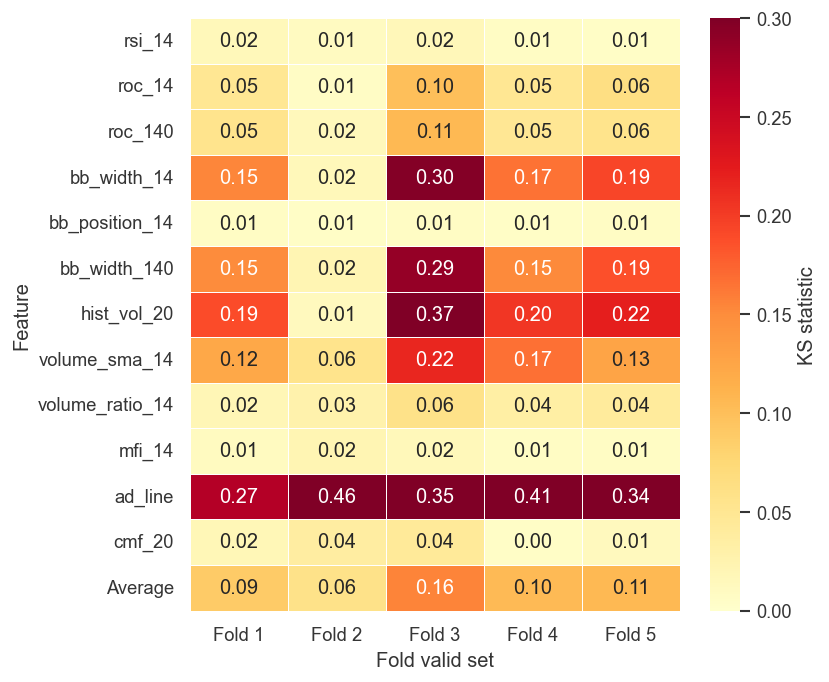

**Finding:** ✅ Test avg KS > 0.20 on 0/5 features — test broadly within CV distribution.

In [18]:
#| label: fig-test-ks-heatmap
#| fig-cap: "KS statistic: test set vs each fold valid set (representative features)"

test_ks: dict[str, dict] = {}
for fold_label, fold_df in valid_dfs.items():
    test_ks[fold_label] = {}
    for feat in REPR_FLAT:
        a = test_data[feat].dropna().values
        b = fold_df[feat].dropna().values
        test_ks[fold_label][feat] = float(stats.ks_2samp(a, b)[0]) if len(a) > 0 and len(b) > 0 else np.nan

test_ks_df = pd.DataFrame(test_ks, index=REPR_FLAT)
test_ks_df.index = [i.replace("feat_", "") for i in test_ks_df.index]
test_ks_df.loc["Average"] = test_ks_df.mean(axis=0)

fig, ax = plt.subplots(figsize=(7, max(4, (len(REPR_FLAT) + 1) * 0.45)))
sns.heatmap(test_ks_df, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=0.3,
            linewidths=0.3, ax=ax, cbar_kws={"label": "KS statistic"})
ax.set_xlabel("Fold valid set")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

avg_test_ks = float(test_ks_df.loc["Average"].mean())
high_avg    = int((test_ks_df.loc["Average"] > 0.20).sum())
total_feats = int(test_ks_df.loc["Average"].notna().sum())
if high_avg <= total_feats / 2:
    display(Markdown(f"**Finding:** ✅ Test avg KS > 0.20 on {high_avg}/{total_feats} features — test broadly within CV distribution."))
else:
    display(Markdown(f"**Finding:** ⚠️ Test avg KS > 0.20 on {high_avg}/{total_feats} features — notable distribution shift between CV and test periods."))

### 6.3 Target positive rate — test vs CV

**Purpose.** Checks whether the test set's class balance is consistent with the CV valid fold distribution.

**Method.** Compute positive rate for each target in the test set and compare to the mean ± std of valid fold positive rates.

**Interpretation.** Test rate within 1 std of CV mean is healthy. Outlier balance may indicate regime change in the test period.

**Action rule.** Test rate deviates > 2 std from CV mean for either target → flag in Summary.

In [19]:
#| label: tbl-test-target-rate
#| tbl-cap: "Target positive rate: test set vs CV valid folds"

test_tgt = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .filter(pl.col("segment") == "test")
    .select(TARGETS)
    .collect()
    .to_pandas()
)

rate_rows = []
for target in TARGETS:
    test_rate = float(test_tgt[target].dropna().mean())
    rate_col  = "rate_l" if "_l_" in target else "rate_s"
    cv_valid  = rate_df[(rate_df["split"] == "valid") & rate_df["fold"].notna()][rate_col]
    cv_mean   = float(cv_valid.mean())
    cv_std    = float(cv_valid.std())
    z         = (test_rate - cv_mean) / cv_std if cv_std > 0 else 0.0
    rate_rows.append({
        "Target": target,
        "test_positive_rate": test_rate,
        "cv_valid_mean_rate": cv_mean,
        "cv_valid_std": cv_std,
        "z_score": round(z, 2),
    })

rate_cmp = pd.DataFrame(rate_rows)
display_analysis_table(rate_cmp)

for _, row in rate_cmp.iterrows():
    if abs(row["z_score"]) <= 2:
        display(Markdown(f"**Finding [{row['Target']}]:** ✅ Test positive rate {row['test_positive_rate']:.2%} within 2 std of CV mean {row['cv_valid_mean_rate']:.2%} (z = {row['z_score']:.2f})."))
    else:
        display(Markdown(f"**Finding [{row['Target']}]:** ⚠️ Test positive rate {row['test_positive_rate']:.2%} deviates {row['z_score']:.2f} std from CV mean — possible regime shift."))

Target,test_positive_rate,cv_valid_mean_rate,cv_valid_std,z_score
trg_l_fw60_q90,3.46%,7.32%,0.029,-1.340
trg_s_fw60_q10,3.74%,6.94%,0.025,-1.280


**Finding [trg_l_fw60_q90]:** ✅ Test positive rate 3.46% within 2 std of CV mean 7.32% (z = -1.34).

**Finding [trg_s_fw60_q10]:** ✅ Test positive rate 3.74% within 2 std of CV mean 6.94% (z = -1.28).

## 7. Metodológiai ellenőrzések (ML checklist)

### 7.1 Embargo gap ellenőrzés

**Purpose.** Verifies the minimum gap between each fold's last training row and first validation row is at least 60 bars (= `target_horizon_minutes`).

**Method.** For each fold: `MIN(valid open_time) − MAX(train open_time)` computed directly from the parquet `open_time` column, filtered by `segment`.

**Interpretation.** Gap must be ≥ 60 minutes. Any fold failing this rule has target leakage.

**Action rule.** A single failing fold is a hard blocker.

In [20]:
#| label: tbl-embargo-gap
#| tbl-cap: "Embargo gap per fold: MIN(valid open_time) − MAX(train open_time)"

embargo_rows = []
for fold_n in range(1, N_FOLDS + 1):
    max_train = (
        pl.scan_parquet(str(SAMPLE_PARQUET))
        .filter(pl.col("segment") == f"fold_{fold_n}_train")
        .select(pl.col("open_time").max())
        .collect()["open_time"][0]
    )
    min_valid = (
        pl.scan_parquet(str(SAMPLE_PARQUET))
        .filter(pl.col("segment") == f"fold_{fold_n}_valid")
        .select(pl.col("open_time").min())
        .collect()["open_time"][0]
    )
    gap_minutes = int((min_valid - max_train).total_seconds() / 60)
    embargo_rows.append({
        "Fold": fold_n,
        "Max train open_time": str(max_train)[:19],
        "Min valid open_time": str(min_valid)[:19],
        "gap_minutes": gap_minutes,
        "Pass (≥60 min)": "✅" if gap_minutes >= HORIZON else "❌",
    })

embargo_df = pd.DataFrame(embargo_rows)
display_analysis_table(embargo_df)

failing = embargo_df[embargo_df["Pass (≥60 min)"] == "❌"]
if failing.empty:
    display(Markdown(f"**Finding:** ✅ All {N_FOLDS} folds satisfy the {HORIZON}-bar embargo rule."))
else:
    display(Markdown(f"**Finding:** ❌ {len(failing)} fold(s) violate the embargo — BLOCKER. Folds: {failing['Fold'].tolist()}"))

Fold,Max train open_time,Min valid open_time,gap_minutes,Pass (≥60 min)
1,2022-09-30 22:59:00,2022-10-01 00:00:00,61,✅
2,2023-03-29 22:59:00,2023-03-30 00:00:00,61,✅
3,2023-09-25 22:59:00,2023-09-26 00:00:00,61,✅
4,2024-03-23 22:59:00,2024-03-24 00:00:00,61,✅
5,2024-09-19 22:59:00,2024-09-20 00:00:00,61,✅


**Finding:** ✅ All 5 folds satisfy the 60-bar embargo rule.

### 7.2 Duplikált `open_time` értékek

**Purpose.** Detects duplicate timestamps within each segment.

**Method.** Groups by `open_time` per segment, counts groups with more than one occurrence.

**Interpretation.** Zero duplicates is expected. Any duplicate is a data integrity error.

**Action rule.** Duplicates > 0 → hard blocker.

In [21]:
#| label: tbl-duplicates
#| tbl-cap: "Duplicate open_time count per segment"

dup_rows = []
for seg in ALL_SEGS:
    dup_count = (
        pl.scan_parquet(str(SAMPLE_PARQUET))
        .filter(pl.col("segment") == seg)
        .select("open_time")
        .group_by("open_time")
        .agg(pl.len().alias("n"))
        .filter(pl.col("n") > 1)
        .collect()
        .height
    )
    dup_rows.append({"segment": seg, "duplicate_open_times": dup_count})

dup_df = pd.DataFrame(dup_rows)
display_analysis_table(dup_df)

total_dups = int(dup_df["duplicate_open_times"].sum())
if total_dups == 0:
    display(Markdown("**Finding:** ✅ Zero duplicate `open_time` values across all segments."))
else:
    display(Markdown(f"**Finding:** ❌ {total_dups} duplicate `open_time` values found — BLOCKER."))

segment,duplicate_open_times
fold_1_train,0
fold_1_valid,0
fold_2_train,0
fold_2_valid,0
fold_3_train,0
fold_3_valid,0
fold_4_train,0
fold_4_valid,0
fold_5_train,0
fold_5_valid,0


**Finding:** ✅ Zero duplicate `open_time` values across all segments.

### 7.3 Feature availability timestamp

**Purpose.** Confirms that features are computed using only closed-bar data (t-1 lag), preventing look-ahead bias.

**Method.** Checks `available_ts <= open_time` for all rows in the parquet. The `available_ts` column records when the feature was made available; it must not exceed the bar's opening timestamp.

**Interpretation.** Zero violations = no look-ahead. Any violation is a hard blocker.

**Action rule.** Violations > 0 → hard blocker.

In [22]:
violations = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .filter(pl.col("available_ts") > pl.col("open_time"))
    .select(pl.len())
    .collect()[0, 0]
)
total_rows = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .select(pl.len())
    .collect()[0, 0]
)
print(f"Total rows: {total_rows:,} | Violations (available_ts > open_time): {violations}")
if violations == 0:
    display(Markdown(f"**Finding:** ✅ No feature availability violations in {total_rows:,} rows — t-1 lag invariant holds."))
else:
    display(Markdown(f"**Finding:** ❌ {violations:,} rows violate `available_ts > open_time` — BLOCKER. Look-ahead leakage detected."))

Total rows: 9,669,301 | Violations (available_ts > open_time): 0


**Finding:** ✅ No feature availability violations in 9,669,301 rows — t-1 lag invariant holds.

### 7.4 NULL target szemantika ellenőrzés

**Purpose.** Verifies that NULL target values appear only at the dataset tail (last 60 bars), as expected from the forward-return window construction.

**Method.** Finds the first NULL `open_time`, then counts any non-null rows after that point. If none exist, NULLs are correctly at the tail.

**Interpretation.** NULLs only at tail = correct semantics. NULLs mid-sample = target construction bug.

**Action rule.** Any early-NULL count > 0 → hard blocker, create a todo ticket for the Database Agent.

In [23]:
null_rows_all = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .filter(pl.col("trg_l_fw60_q90").is_null() | pl.col("trg_s_fw60_q10").is_null())
    .select(["open_time", "trg_l_fw60_q90", "trg_s_fw60_q10"])
    .sort("open_time")
    .collect()
)

max_non_null_ts = (
    pl.scan_parquet(str(SAMPLE_PARQUET))
    .filter(pl.col("trg_l_fw60_q90").is_not_null())
    .select(pl.col("open_time").max())
    .collect()["open_time"][0]
)

null_count = null_rows_all.height
min_null_ts = null_rows_all["open_time"].min() if null_count > 0 else None

early_nulls = 0
if min_null_ts is not None and max_non_null_ts is not None:
    if min_null_ts <= max_non_null_ts:
        early_nulls = int(
            pl.scan_parquet(str(SAMPLE_PARQUET))
            .filter(
                (pl.col("trg_l_fw60_q90").is_null() | pl.col("trg_s_fw60_q10").is_null())
                & (pl.col("open_time") <= max_non_null_ts)
            )
            .select(pl.len())
            .collect()[0, 0]
        )

print(f"NULL target rows: {null_count:,}")
print(f"First NULL open_time: {min_null_ts}")
print(f"Last non-NULL open_time: {max_non_null_ts}")
print(f"Early NULLs (before last non-null): {early_nulls}")

if early_nulls == 0:
    display(Markdown(f"**Finding:** ✅ All {null_count:,} NULL target rows are at the dataset tail — consistent with {HORIZON}-bar forward window."))
else:
    display(Markdown(f"**Finding:** ❌ {early_nulls:,} NULL target rows appear before the dataset tail — BLOCKER. Target construction error."))

NULL target rows: 0
First NULL open_time: None
Last non-NULL open_time: 2026-05-31 23:59:00
Early NULLs (before last non-null): 0


**Finding:** ✅ All 0 NULL target rows are at the dataset tail — consistent with 60-bar forward window.

## 8. Summary

In [24]:
# Aggregate findings from prior cells
data_start  = FOLDS[0]["train_start"][:10]
data_end    = TEST_INFO["end"][:10]

long_rates  = cv_only[cv_only["split"] == "valid"]["rate_l"].values
short_rates = cv_only[cv_only["split"] == "valid"]["rate_s"].values
long_ok     = all(0.08 <= r <= 0.12 for r in long_rates if not np.isnan(r))
short_ok    = all(0.08 <= r <= 0.12 for r in short_rates if not np.isnan(r))

top_drift_feat = str(drift.iloc[0]["feature"]) if len(drift) > 0 else "N/A"
top_drift_val  = float(drift.iloc[0]["drift_std"]) if len(drift) > 0 else 0.0

blockers: list[str] = []
if not failing.empty:
    blockers.append(f"Embargo gap violation in fold(s) {failing['Fold'].tolist()}")
if total_dups > 0:
    blockers.append(f"{total_dups} duplicate open_time values")
if violations > 0:
    blockers.append(f"{violations:,} feature availability violations (look-ahead)")
if early_nulls > 0:
    blockers.append(f"{early_nulls:,} early NULL target rows")

verdict = (
    "✅ **SUITABLE FOR MODELLING** — all methodological checks pass"
    if not blockers else
    f"❌ **BLOCKED — {len(blockers)} blocker(s) must be resolved before training**"
)

blocker_list = "\n".join(f"  - {b}" for b in blockers) if blockers else "  None"

display(Markdown(f"""
### Sample: `{SAMPLE_ID}`

| Dimension | Value |
|---|---|
| Date range | {data_start} → {data_end} |
| Total sample rows | {total_rows:,} |
| Folds | {N_FOLDS} (expanding window) |
| Features | {len(FEAT_COLS)} |
| Forward horizon | {HORIZON} bars |

**Target positive rate (CV valid folds):**  
Long (q90): avg {float(np.nanmean(long_rates)):.2%}, std {float(np.nanstd(long_rates)):.2%} → {'✅ within 8–12%' if long_ok else '⚠️ out-of-band in some folds'}  
Short (q10): avg {float(np.nanmean(short_rates)):.2%}, std {float(np.nanstd(short_rates)):.2%} → {'✅ within 8–12%' if short_ok else '⚠️ out-of-band in some folds'}

**Feature drift (KS test across fold valid sets):**  
Most-drifting feature: `{top_drift_feat}` (fold-median std = {top_drift_val:.4f})  
{pct:.1f}% of representative-feature KS cells exceed 0.15 vs fold 1 reference.

**Multicollinearity:**  
{len(pairs_df)} feature pairs |r| > 0.90 — {'manageable for LightGBM' if len(pairs_df) <= 30 else 'consider feature pruning'}.

**Test vs CV similarity:**  
Average KS distance (test vs CV valid) across representative features: {avg_test_ks:.3f}  
Test KS > 0.20 on {high_avg}/{total_feats} representative features.

**Methodological checks:**  
- Embargo gap (≥ {HORIZON} bars): {'✅ All folds pass' if failing.empty else f'❌ {len(failing)} fold(s) fail'}  
- Duplicate timestamps: {'✅ None' if total_dups == 0 else f'❌ {total_dups} duplicates'}  
- Feature availability (no look-ahead): {'✅ No violations' if violations == 0 else f'❌ {violations} violations'}  
- NULL target semantics: {'✅ All NULLs at tail' if early_nulls == 0 else f'❌ {early_nulls} early NULLs'}

**Blockers:**  
{blocker_list}

---

### Verdict

{verdict}
"""))


### Sample: `solusdt_fw60_2010_2605`

| Dimension | Value |
|---|---|
| Date range | 2020-10-01 → 2026-05-31 |
| Total sample rows | 9,669,301 |
| Folds | 5 (expanding window) |
| Features | 208 |
| Forward horizon | 60 bars |

**Target positive rate (CV valid folds):**  
Long (q90): avg 7.32%, std 2.59% → ⚠️ out-of-band in some folds  
Short (q10): avg 6.94%, std 2.23% → ⚠️ out-of-band in some folds

**Feature drift (KS test across fold valid sets):**  
Most-drifting feature: `feat_obv` (fold-median std = 9689400.5259)  
20.8% of representative-feature KS cells exceed 0.15 vs fold 1 reference.

**Multicollinearity:**  
116 feature pairs |r| > 0.90 — consider feature pruning.

**Test vs CV similarity:**  
Average KS distance (test vs CV valid) across representative features: 0.102  
Test KS > 0.20 on 0/5 representative features.

**Methodological checks:**  
- Embargo gap (≥ 60 bars): ✅ All folds pass  
- Duplicate timestamps: ✅ None  
- Feature availability (no look-ahead): ✅ No violations  
- NULL target semantics: ✅ All NULLs at tail

**Blockers:**  
  None

---

### Verdict

✅ **SUITABLE FOR MODELLING** — all methodological checks pass
